[Video by Andrej Karpathy](https://www.youtube.com/watch?v=l8pRSuU81PU)

This notebook is thoroughly going through the content of the video as it document and comment for self-education purposes.

*Vibe check to ensure it works at its supposed env*

In [1]:
!python --version

Python 3.12.11


In [2]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2023 NVIDIA Corporation
Built on Fri_Jan__6_16:45:21_PST_2023
Cuda compilation tools, release 12.0, V12.0.140
Build cuda_12.0.r12.0/compiler.32267302_0


*Get cuda to work in GPU if available*

Find your cuda version: https://pytorch.org/get-started/locally/

Replace the url below

In [3]:
# !pip3 install torch --index-url https://download.pytorch.org/whl/cu126

In [4]:
import torch
from torch.nn import functional as F
import math

In [5]:
torch.cuda.is_available()

True

In [6]:
! pip install transformers matplotlib 

*Check if gpu is cuda accessible.*

In [7]:
!nvidia-smi

Thu Jun 12 10:06:34 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.04              Driver Version: 576.52         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 Ti     On  |   00000000:01:00.0  On |                  N/A |
| 38%   58C    P2             68W /  225W |    3984MiB /   8192MiB |      6%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Pre-Text

Related papers,
- [Paper, Attention Is All You Need](https://arxiv.org/abs/1706.03762)
- [GPT-2 Paper, Language Models are Unsupervised Multitask Learners](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)
 - [Code for paper](https://github.com/openai/gpt-2)
 - This paper got some errors in calculation and details, where GPT-3's paper can cover for it, which is close in terms of architecture.
- [GPT-3 Paper, Language Models are Few-Shot Learners](https://arxiv.org/abs/2005.14165)
 - [Code for paper](https://github.com/openai/gpt-3)

Supplementary sites for the video,
- [Build nanogpt by Andrej Karpathy](https://github.com/karpathy/build-nanogpt)

Extra to note,
- [LitGPT](https://github.com/Lightning-AI/litgpt)
- [TinyLlama](https://github.com/jzhang38/TinyLlama)

In [8]:
# Note that the model implemented here is the smallest model of GPT-2 with
#   12 layers and 768 channnels/dimensions.
# GPT-2 paper had error during calculation (mentioned in their git repository)

Sources of images, GPT-2 paper

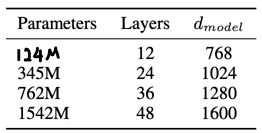

In [9]:
# The bottom chart is to show the validation loss
# of next token prediction in a sequence

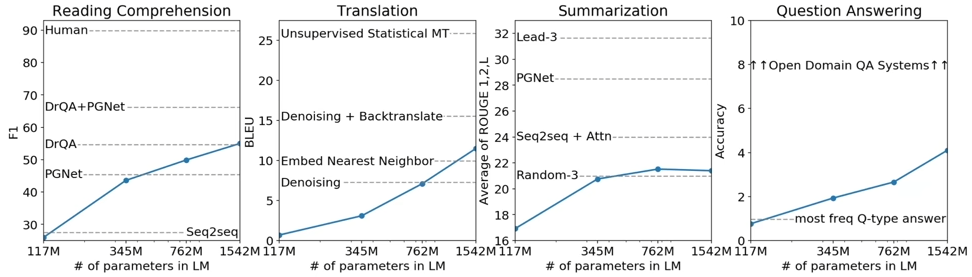

# GPT-2 (124M) Checkpoint exploring: Hugging-face implementation of GPT-2

[Code of GPT-2 by HuggingFace](https://github.com/huggingface/transformers/blob/main/src/transformers/models/gpt2/modeling_gpt2.py)

[HuggingFace page for GPT2](https://huggingface.co/openai-community/gpt2)

In [10]:
# The original GPT-2 code was programmed using Tensorflow
# which is not used as PyTorch nowadays which is friendlier and cleaner.

In [11]:
from transformers import GPT2LMHeadModel
model_hf = GPT2LMHeadModel.from_pretrained("gpt2")    # 124M
# model_hf = GPT2LMHeadModel.from_pretrained("gpt2-xl") # 1542M

# Get raw tensors
sd_hf = model_hf.state_dict()

for k, v in sd_hf.items():
  print(k, v.shape)

# transformer.wte.weight torch.Size([50257, 768])
# 50257 tokens in gpt2 vocabulary
# 768 dimensionsional embedding, vector that represents that token
#     used to capture semantic and syntactic information that token has,
#     preserving important relationships and structures.

# transformer.wpe.weight torch.Size([1024, 768])
# Positional embedding and token embedding.
# GPT2 has maximum context length of 1024,
# Up to 1024 positions that each token can be attending to,
# and each token has 768 fixed vector that is learned by optimization.

# The rest are just weights and biases of the GPT2 transformer
#   transformer.h.0.ln_1.weight torch.Size([768])
#   transformer.h.11.ln_1.weight torch.Size([768])
# There are 12 layers in this Transformer

/root/miniconda3/envs/AI_LLM/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

In [12]:
sd_hf["transformer.wpe.weight"].view(-1)[:20] # weight positional embedding

tensor([-0.0188, -0.1974,  0.0040,  0.0113,  0.0638, -0.1050,  0.0369, -0.1680,
        -0.0491, -0.0565, -0.0025,  0.0135, -0.0042,  0.0151,  0.0166, -0.1381,
        -0.0063, -0.0461,  0.0267, -0.2042])

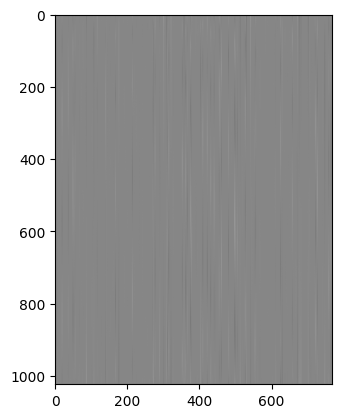

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(sd_hf["transformer.wpe.weight"], cmap="gray")

# Positional embedding has structure.
# Every row in this visualization is a different position.
# A fixed absolute position in the range from 0-1024,
# Each row is representation of that position.

# The positional embedding end up learning
# sine and cosine representation of these positions
# and is pocessed by the Transformer
# to recover all relative positions and realize which token is where
# and attend to them depending on their position, not just content.

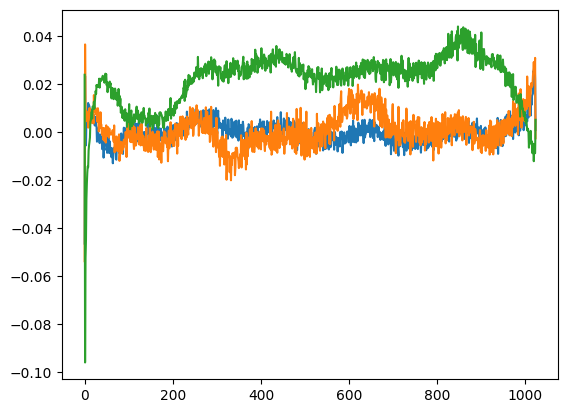

In [14]:
# Looking into individual column, grab 3 random columns
plt.plot(sd_hf["transformer.wpe.weight"][:, 150])
plt.plot(sd_hf["transformer.wpe.weight"][:, 200])
plt.plot(sd_hf["transformer.wpe.weight"][:, 250])

# Is a function of position from 0 to 1223

In [15]:
# Green barely fires at 0, likes to fire for everything after 200 up to 800, etc.

# This model is not fully trained, as seen from the jagged-ness (noisy).
# The more trained the model, the smoother the graph.

# It is telling you this is an undertrained model.
# It's kind of a sinusoidal feature during optimization

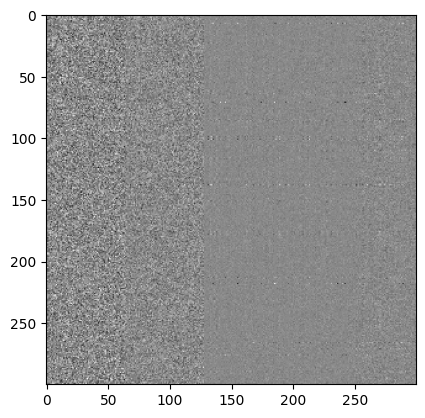

In [16]:
plt.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"][:300,:300], cmap="gray")
# First layer of transformer, look at its weights
# Some structures can be seen. (mechanistic interpretability <- a new field)

[HuggingFace Pipeline](https://huggingface.co/docs/transformers/en/main_classes/pipelines)

In [17]:
from transformers import pipeline, set_seed
generator = pipeline('text-generation', model='gpt2')
set_seed(42)
generator("Hello, I'm a language model,", max_length=30, num_return_sequences=5)

# Load (raw) weights of this model (released by openAI)
# We can also get pipeline and sample from it.
# Pipeline is a HuggingFace Transformer thing.

# Sample 30 tokens, get 5 sequences.

# Although same seed from GPT-2 HF site, it generated different things.

Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "Hello, I'm a language model, so I can write things that are easy to understand with a little bit of code. But when you think of words, it's hard to think of words that are as simple as a little word in a sentence.\n\nSo I'm going to use a little bit of code, and I'll talk a little bit about the syntax.\n\nThis is how you write your first line:\n\n$trans = new $trans [1, 2, 3, 4]; $trans -> write ( 'Hello, I'm a language model, so I can write things that are easier to understand with a little bit of code.' );\n\nThis code is pretty simple, but it really doesn't have to be. We want to write this code in a few lines, and we're going to use an expression, which is a collection of $trans. We'll use the following syntax:\n\n$trans = new $trans [1, 2, 3, 4];\n\nNow what we're going to do is we're going to look for a line that begins with a semicolon, and then uses the word 'hello' in place of a semicolon. We'll also use the following code to write a couple of lines of cod

# Section 1: Implement GPT-2 nn.Module

- [Paper, Attention Is All You Need](https://arxiv.org/abs/1706.03762)

Main differences between Transformer and GPT-2 model.
1. GPT-2 is a `Decoder only` Transformer, it does not have encoder part of Transformer.
2. No Cross Attention (Used for Encoder)

1. Layer Normalization was moved to input of each sub-block (Similar to a pre-activation residual network)
2. An additional Layer Normalization was added after the final self-
attention block.

Transformer architecture

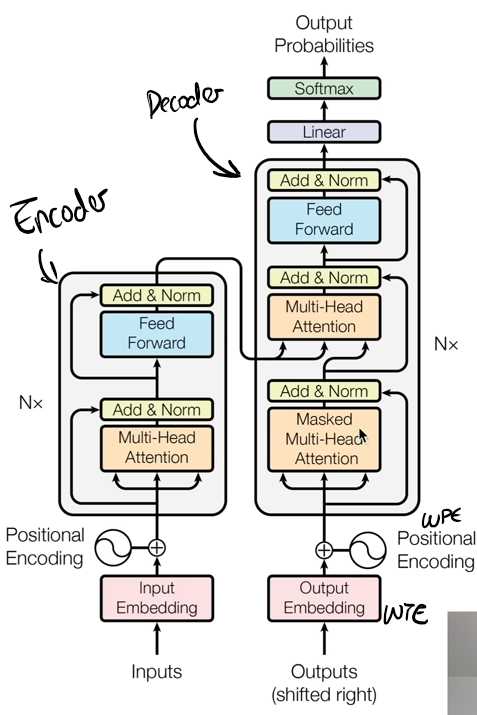

GPT-2 roughly is

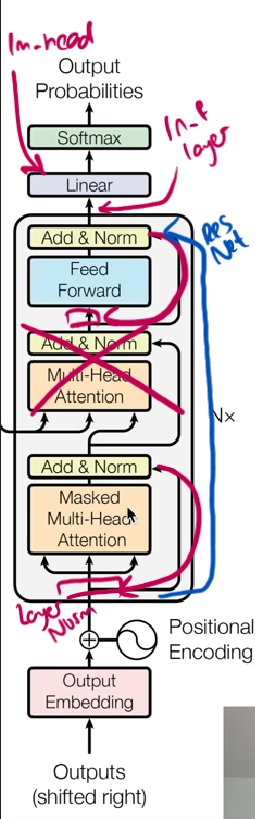

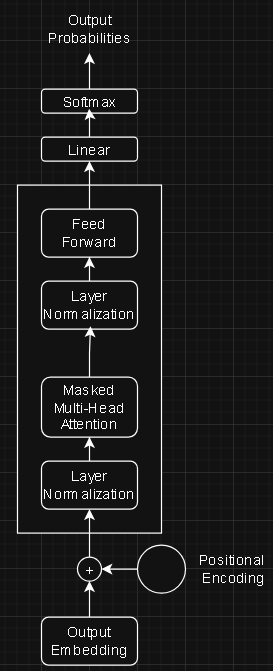

In [18]:
# NOTE:
# The normalization are inside residual stream
#   Feed forward is applied, which goes through normalization
#   Residual pathway has normalizations inside them;
#   Normalization is inside Residual
# We want Residual pathway to be clean,
# from Supervision to inputs of tokens.
# Desirable because gradients flow from top, distributes gradients during backwards.

# This is not ideal nor desirable

## Code

In [19]:
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as f

In [20]:
@dataclass
class GPTConfig:
  block_size: int = 256
  vocab_size: int = 65
  n_layer: int = 6
  n_head: int = 6
  n_embd: int = 384

class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

## Update 1:

In [21]:
@dataclass
class GPTConfig:
  block_size: int = 256
  vocab_size: int = 65
  n_layer: int = 6
  n_head: int = 6
  n_embd: int = 384


class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

    self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd), # Output Embedding
        wpe = nn.Embedding(config.block_size, config.n_embd), # Positional Embedding
        # As seen in the pretrained, h layers can be indexed to create 12 layers
        # h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]), # Nx in image
        ln_f = nn.LayerNorm(config.n_embd),
    ))
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

## Update 2:

In [22]:
class MLP(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.c_fc   = nn.Linear(config.n_embd, 4 * config.n_embd)
    self.gelu   = nn.GELU(approximate='tanh')
    self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd)

  def forward(self, x):
    x = self.c_fc(x)
    x = self.gelu(x)
    x = self.c_proj(x)
    return x

### NOTE: GELU

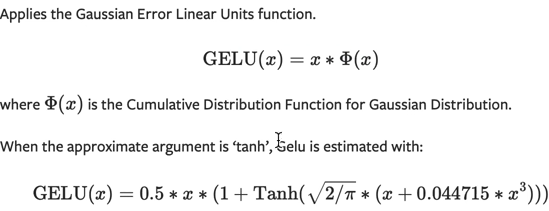

[Source: Pytorch](https://docs.pytorch.org/docs/stable/generated/torch.nn.GELU.html)

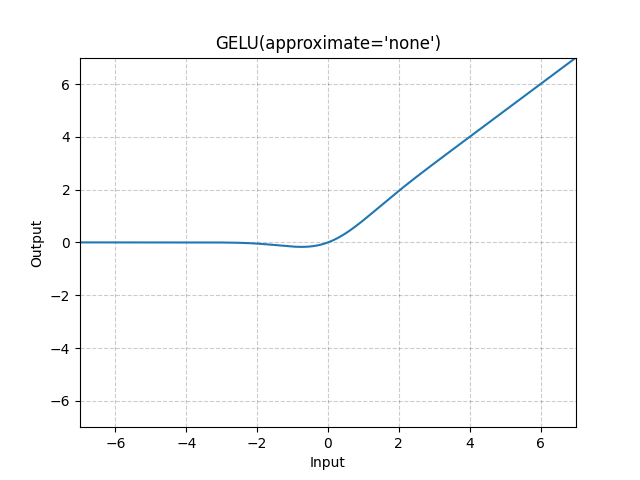

- Basically, it's ReLU but tail is not that flat at 0 Input.
- Kinda like have a fall cushion.GeLU always have a local gradient(Allowing negative inputs close to 0 still get activation instead of flat out 0).
- Removes the "dead ReLU" neurons problem.

NOTE:
- Basically, don't use the approx. version, just use the regular version.

### Code Cont.

In [23]:
class CausalSelfAttention(nn.Module):
  # Multi-Headed Attention

  def __init__(self, config):
    super().__init__()
    assert config.n_embd % config.n_head == 0
    # Key, Query, Value projections for all heads, but in a batch
    self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
    # Output projection
    self.c_proj = nn.Linear(config.n_embd, config.n_embd)
    # Regularization
    self.n_head = config.n_head
    self.n_embd = config.n_embd
    # Not really a "bias", closer to a mask
    # Following OpenAI/HF naming
    self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                  .view(1, 1, config.block_size, config.block_size))

  def forward(self, x):
    # Batch size, sequence length, embedding dimensionality(n_embd)
    B, T, C = x.size()
    # Calculate Key, Query, Value for all heads in batch
    # and move head forward to be batch
    # nh is "Number of heads", hs is "head size", C (number of channels) = nh * ns
    # E.g. GPT-2 (124M), n_heads=12, hs=64, so nh*hs=C=768 channels in Transformer
    qkv = self.c_attn(x)
    q, k, v = qkv.split(self.n_embd, dim=2)
    k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
    q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
    v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
    # Attention (materializes the large (T, T) matrix for all the queries and keys)
    att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
    att = att.masked_fill(self.bias[:,:,:T,:T]==0, float('-inf')) # Consider tokens before, not after it
    att = F.softmax(att, dim=-1) # Sum = 1
    y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
    y = y.transpose(1, 2).contiguous().view(B, T, C) # Re-assemble all head outputs side by side
    # Output projection
    y = self.c_proj(y)
    return y

In [24]:
class Block(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.ln_1 = nn.LayerNorm(config.n_embd)
    self.attn = CausalSelfAttention(config) # Reduction
    self.ln_2 = nn.LayerNorm(config.n_embd)
    self.mlp = MLP(config) # Mapping

  def forward(self, x):
    # Residual channel preferably clean
    # from supervision to token input.
    # Gradient flow without normalization in between.
    # From optimization perspective.
    # This is pre-normalization layer. Feed-Forward Network.
    x = x + self.attn(self.ln_1(x))
    x = x + self.mlp(self.ln_2(x))
    # Layer Norm is after Attention
    return x

In [25]:
@dataclass
class GPTConfig:
  block_size: int = 1024 # Max sequence length
  vocab_size: int = 50257 # No. tokens: 50,000 BPE merges + 256 bytes tokens + 1 <|endoftext|>
  n_layer: int = 12 # Number of layers
  n_head: int = 12 # Number of heads
  n_embd: int = 768 # Embedding dimensions

class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

    self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd), # Output Embedding
        wpe = nn.Embedding(config.block_size, config.n_embd), # Positional Embedding
        # As seen in the pretrained, h layers can be indexed to create 12 layers
        h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]), # Nx in image
        ln_f = nn.LayerNorm(config.n_embd),
    ))
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

  @classmethod
  def from_pretrained(cls, model_type):
    """ Loads pretrained GPT-2 model weights from HuggingFace """
    assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
    from transformers import GPT2LMHeadModel
    print("loading weights from pretrained gpt: %s" % model_type)

    # n_layer, n_head and n_embd are determined from model_type
    config_args = {
        'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
        'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
        'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
        'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
    }[model_type]
    config_args['vocab_size'] = 50257 # Always 50257 for GPT model checkpoints
    config_args['block_size'] = 1024 # Always 1024 for GPT model checkpoints
    # Create a from-scratch initialized minGPT model
    config = GPTConfig(**config_args)
    model = GPT(config)
    sd = model.state_dict()
    sd_keys = sd.keys()
    sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # Discard this mask / buffer, not a param

    # Init a huggingface/transformers model
    model_hf = GPT2LMHeadModel.from_pretrained(model_type)
    sd_hf = model_hf.state_dict()

    # Copy while ensuring all of the parameters are aligned and match in names and shapes
    sd_keys_hf = sd_hf.keys()
    sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # Ignore, just a buffer
    sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # Ignore, just the mask (buffer)
    transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
    # Basically OpenAI checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear.
    # This means that we have to transpose these weights when we import them.
    assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
    for k in sd_keys_hf:
        if any(k.endswith(w) for w in transposed):
            # Special treatment for the Conv1D weights we need to transpose
            assert sd_hf[k].shape[::-1] == sd[k].shape
            with torch.no_grad():
                sd[k].copy_(sd_hf[k].t())
        else:
            # Vanilla copy over the other parameters
            assert sd_hf[k].shape == sd[k].shape
            with torch.no_grad():
                sd[k].copy_(sd_hf[k])

    return model

  def forward(self, idx):
    # idx is of shape (B, T)
    B, T = idx.size()
    assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
    # Forward the token and posisition embeddings
    pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
    pos_emb = self.transformer.wpe(pos) # Position embeddings of shape (T, n_embd)
    tok_emb = self.transformer.wte(idx) # Token embeddings of shape (B, T, n_embd)
    x = tok_emb + pos_emb # Broadcasting happening here
    # Forward the blocks of the transformer
    for block in self.transformer.h:
        x = block(x)
    # Forward the final layernorm and the classifier
    x = self.transformer.ln_f(x)
    logits = self.lm_head(x) # (B, T, vocab_size)
    return logits

In [26]:
model = GPT.from_pretrained('gpt2')
print("Loaded")

loading weights from pretrained gpt: gpt2
Loaded


In [27]:
num_return_sequences = 5
max_length = 30

# Commented to avoid error - vibe check
model.eval()
model.to('cuda')

GPT(
  (transformer): ModuleDict(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (h): ModuleList(
      (0-11): 12 x Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=768, out_features=2304, bias=True)
          (c_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (gelu): GELU(approximate='tanh')
          (c_proj): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [28]:
%pip install tiktoken

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [29]:
import tiktoken 
enc = tiktoken.get_encoding('gpt2')
tokens = enc.encode("Hello, I'm a language model,")
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1) # (5, 8)
x = tokens.to('cuda')

In [30]:
# Generate. x = (B,T), B=5, T=8
# Set seed = 42
torch.manual_seed(42)
torch.cuda.manual_seed(42)
while x.size(1) < max_length:
    # Forward the model to get logits
    with torch.no_grad():
        logits = model(x) # (B, T, vocab_size)
        # Take logits at last position (Predicted)
        logits = logits[:, -1, :] # (B, vocab_size)
        # Get probabilities
        probs = F.softmax(logits, dim=-1)
        # Do Top-K sampling of 50 (HugginFace pipeline default)
        # topk_probs = (5, 50)
        # topk_indiecs = (5, 50)
        topk_probs, topk_indices = torch.topk(probs, 50, dim=-1) # DEBUG: Don't know why first time it error "unexpected: dim param"
        # Select a token from top-k probabilities
        ix = torch.multinomial(topk_probs, 1) # (B, 1)
        # Gather corresponding indices
        xcol = torch.gather(topk_indices, -1, ix) # (B, 1)
        # Append to the sequence
        x = torch.cat((x, xcol), dim=1)

#### Note: Auto-detect hardware

In [31]:
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps" # Multi-Process Server
print(f"Using device: {device}")

Using device: cuda


In [32]:
# NOTE: torch.compile actually optimizes the whole process efficiently.

In [33]:
# Print the generated text
for i in range(num_return_sequences):
    tokens = x[i, :max_length].tolist()
    decoded = enc.decode(tokens)
    print(">", decoded)

> Hello, I'm a language model, not a program.

So this morning I started studying for the interview in the lab. This was not
> Hello, I'm a language model, and one of the main things that bothers me when they create languages is how easy it becomes to create something that
> Hello, I'm a language model, and I wrote it off on the grounds that a language model would make me more fluent. But I'm not
> Hello, I'm a language model, I really like languages. I like languages because like, they're good. And the way we talk about languages
> Hello, I'm a language model, a language model I'm using for data modelling. All I did was test the results and then I wrote some


## Training the Dataset

Using TinyShakespear dataset

In [34]:
# Google Colab
# !wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt 

# Jupyter Notebook
def get_dataset():
    import urllib.request
    url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
    with urllib.request.urlopen(url) as response:
        raw_bytes = response.read()
        text = raw_bytes.decode('utf-8')
        # Equivalent of word count (wc third party library)
        print("Lines: "+ str(len(text.splitlines())), '| Words: ' + str(len(text.split())), '| Bytes: '+ str(len(raw_bytes)))
        # This file only has ASCII characters
    return text

In [35]:
text = get_dataset()
data = text[:1000] # Data is first 1000 characters (~3000 tokens)

Lines: 40000 | Words: 202651 | Bytes: 1115394


In [36]:
# Tokenize it using Tiktoken
tokens = enc.encode(data)
print(tokens[:24])  

[5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248, 461, 11, 2740, 13]


### Make idx, shape of (B, T) - Training in batch

In [37]:
buf = torch.tensor(tokens[:24+1]) # 24 = B*T # +1 is Ground truth at last token
x = buf[:-1].view(4, 6) # Input to Transformer
y = buf[1:].view(4, 6)# Label for training (with ground truth)
print(x)
print(y) # Final token 198 is the label for 13

tensor([[ 5962, 22307,    25,   198,  8421,   356],
        [ 5120,   597,  2252,    11,  3285,   502],
        [ 2740,    13,   198,   198,  3237,    25],
        [  198,  5248,   461,    11,  2740,    13]])
tensor([[22307,    25,   198,  8421,   356,  5120],
        [  597,  2252,    11,  3285,   502,  2740],
        [   13,   198,   198,  3237,    25,   198],
        [ 5248,   461,    11,  2740,    13,   198]])


In [38]:
# Extra: Set x and y to 'cuda' 
x = x.to('cuda')
y = y.to('cuda')
x.is_cuda, y.is_cuda

(True, True)

### Actual training

Update, forward function

In [39]:
@dataclass
class GPTConfig:
  block_size: int = 1024 # Max sequence length
  vocab_size: int = 50257 # No. tokens: 50,000 BPE merges + 256 bytes tokens + 1 <|endoftext|>
  n_layer: int = 12 # Number of layers
  n_head: int = 12 # Number of heads
  n_embd: int = 768 # Embedding dimensions

class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

    self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd), # Output Embedding
        wpe = nn.Embedding(config.block_size, config.n_embd), # Positional Embedding
        # As seen in the pretrained, h layers can be indexed to create 12 layers
        h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]), # Nx in image
        ln_f = nn.LayerNorm(config.n_embd),
    ))
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

  @classmethod
  def from_pretrained(cls, model_type):
    """ Loads pretrained GPT-2 model weights from HuggingFace """
    assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
    from transformers import GPT2LMHeadModel
    print("loading weights from pretrained gpt: %s" % model_type)

    # n_layer, n_head and n_embd are determined from model_type
    config_args = {
        'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
        'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
        'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
        'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
    }[model_type]
    config_args['vocab_size'] = 50257 # Always 50257 for GPT model checkpoints
    config_args['block_size'] = 1024 # Always 1024 for GPT model checkpoints
    # Create a from-scratch initialized minGPT model
    config = GPTConfig(**config_args)
    model = GPT(config)
    sd = model.state_dict()
    sd_keys = sd.keys()
    sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # Discard this mask / buffer, not a param

    # Init a huggingface/transformers model
    model_hf = GPT2LMHeadModel.from_pretrained(model_type)
    sd_hf = model_hf.state_dict()

    # Copy while ensuring all of the parameters are aligned and match in names and shapes
    sd_keys_hf = sd_hf.keys()
    sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # Ignore, just a buffer
    sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # Ignore, just the mask (buffer)
    transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
    # Basically OpenAI checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear.
    # This means that we have to transpose these weights when we import them.
    assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
    for k in sd_keys_hf:
        if any(k.endswith(w) for w in transposed):
            # Special treatment for the Conv1D weights we need to transpose
            assert sd_hf[k].shape[::-1] == sd[k].shape
            with torch.no_grad():
                sd[k].copy_(sd_hf[k].t())
        else:
            # Vanilla copy over the other parameters
            assert sd_hf[k].shape == sd[k].shape
            with torch.no_grad():
                sd[k].copy_(sd_hf[k])

    return model

  def forward(self, idx, targets=None):
    # idx is of shape (B, T)
    B, T = idx.size()
    assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
    # Forward the token and posisition embeddings
    pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
    pos_emb = self.transformer.wpe(pos) # Position embeddings of shape (T, n_embd)
    tok_emb = self.transformer.wte(idx) # Token embeddings of shape (B, T, n_embd)
    x = tok_emb + pos_emb # Broadcasting happening here
    # Forward the blocks of the transformer
    for block in self.transformer.h:
        x = block(x)
    # Forward the final layernorm and the classifier
    x = self.transformer.ln_f(x)
    logits = self.lm_head(x) # (B, T, vocab_size)
    loss = None
    if targets is not None:
      loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1)) # NOTE: cross-entropy uses 2-D
    return logits, loss

In [40]:
model = GPT(GPTConfig())
# model.to(device)
model.to("cuda")
logits, loss = model(x, y)

logits.shape, loss
# loss = 11.xx
# vocab_size = 50257. Ideally every vocab element is roughly uniform at initialization.
# Cross entropy = -loglikelihood
# -ln(1/50257) = ~10.8 ~= 11

(torch.Size([4, 6, 50257]),
 tensor(10.8935, device='cuda:0', grad_fn=<NllLossBackward0>))

### Optimization loop

[torch AdamW paper](https://docs.pytorch.org/docs/stable/generated/torch.optim.AdamW.html)

Optimizes faster than SGD.

In [41]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4) # AdamW is a bug fixed of Adam
steps = 50
for i in range(steps):
    optimizer.zero_grad()
    logits, loss = model(x, y)
    loss.backward()
    optimizer.step()
    print(f"Step {i+1}, Loss: {loss.item()}")

Step 1, Loss: 10.893531799316406
Step 2, Loss: 4.0355305671691895
Step 3, Loss: 1.0962046384811401
Step 4, Loss: 0.33548417687416077
Step 5, Loss: 0.13874876499176025
Step 6, Loss: 0.07092409580945969
Step 7, Loss: 0.04390064254403114
Step 8, Loss: 0.0314694382250309
Step 9, Loss: 0.02475261688232422
Step 10, Loss: 0.02061309665441513
Step 11, Loss: 0.017785822972655296
Step 12, Loss: 0.015686705708503723
Step 13, Loss: 0.014022376388311386
Step 14, Loss: 0.012640193104743958
Step 15, Loss: 0.011460664682090282
Step 16, Loss: 0.010441713035106659
Step 17, Loss: 0.009558296762406826
Step 18, Loss: 0.008792178705334663
Step 19, Loss: 0.008128011599183083
Step 20, Loss: 0.007551256567239761
Step 21, Loss: 0.0070489742793142796
Step 22, Loss: 0.006609143689274788
Step 23, Loss: 0.006221339106559753
Step 24, Loss: 0.005876947659999132
Step 25, Loss: 0.005568338092416525
Step 26, Loss: 0.0052899811416864395
Step 27, Loss: 0.005037340801209211
Step 28, Loss: 0.004806875716894865
Step 29, Loss

It may look good but this is overfitting. The model is memorizing this single individual batch data.

We don't want to overfit a single batch, we want to <u>optimize and iterate over XY batches</u>. We need a dataloader. 

#### Data loader lite

In [42]:
import tiktoken
class DataLoaderLite:
    
    def __init__(self, B, T):
        self.B = B
        self.T = T
    
        # At init, load tokens from disk and store in memory
        text = get_dataset()
        enc = tiktoken.get_encoding('gpt2')
        tokens = enc.encode(text)
        self.tokens = torch.tensor(tokens)
        print(f"Loaded {len(self.tokens)} tokens.")
        print(f"1 epoch = {len(self.tokens) // (B*T)} batches.")
        
        # State
        self.current_position = 0
        
    def next_batch(self):
        B, T = self.B, self.T
        buf = self.tokens[self.current_position : self.current_position+B*T+1]
        x = (buf[:-1]).view(B, T) # Inputs
        y = (buf[1:]).view(B, T)  # Labels/Targets
        # Advance the position in tensor
        self.current_position += B * T
        # If loading next batch would be out of bounds, reset
        if self.current_position + (B * T + 1) > len(self.tokens):
            self.current_position = 0
        return x, y

In [43]:
train_loader = DataLoaderLite(B=4, T=32)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4) # AdamW is a bug fixed of Adam
steps = 50
for i in range(steps):
    x, y = train_loader.next_batch()
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    logits, loss = model(x, y)
    loss.backward()
    optimizer.step()
    print(f"Step {i+1}, Loss: {loss.item()}") 

Lines: 40000 | Words: 202651 | Bytes: 1115394
Loaded 338025 tokens.
1 epoch = 2640 batches.
Step 1, Loss: 7.816648960113525
Step 2, Loss: 11.133648872375488
Step 3, Loss: 11.369466781616211
Step 4, Loss: 10.043526649475098
Step 5, Loss: 9.527843475341797
Step 6, Loss: 9.036561012268066
Step 7, Loss: 9.671114921569824
Step 8, Loss: 9.044543266296387
Step 9, Loss: 8.24924087524414
Step 10, Loss: 8.32138729095459
Step 11, Loss: 8.483295440673828
Step 12, Loss: 7.283949375152588
Step 13, Loss: 7.902469158172607
Step 14, Loss: 7.531759738922119
Step 15, Loss: 7.74044132232666
Step 16, Loss: 7.375670909881592
Step 17, Loss: 7.407823085784912
Step 18, Loss: 8.36848258972168
Step 19, Loss: 7.325920581817627
Step 20, Loss: 7.86885929107666
Step 21, Loss: 7.688366889953613
Step 22, Loss: 7.87204647064209
Step 23, Loss: 6.336824893951416
Step 24, Loss: 6.779581069946289
Step 25, Loss: 6.695058345794678
Step 26, Loss: 6.436450481414795
Step 27, Loss: 6.5717692375183105
Step 28, Loss: 7.54010295867

### BUG: lm_head and wte + Model initialization

Checking lm_head (Top layer at input, upscaling 768 to 50257) and wte (Bottom layer at logits)

In [44]:
sd_hf["lm_head.weight"].shape, sd_hf["transformer.wte.weight"].shape

(torch.Size([50257, 768]), torch.Size([50257, 768]))

In [45]:
# Comparing element-wise equality
(sd_hf["lm_head.weight"] == sd_hf["transformer.wte.weight"]).all()

tensor(True)

In [46]:
# Check data pointers
sd_hf["lm_head.weight"].data_ptr(), sd_hf["transformer.wte.weight"].data_ptr()

(140703393370067, 140703393370067)

These 2 separate tensors not only have the same shapes and elements, they are pointing to the identical tensor.

<u>This is because this is a common weight tying scheme.</u>
> Similar tokens should have similar embeddings or similar weights.

[Paper, Using Output Embedding to Improve Language Models](https://arxiv.org/pdf/1608.05859) | [Paper, Attention is all you need](https://arxiv.org/pdf/1706.03762)

In [47]:
# Basically just add () to init
# Weight Sharing Scheme
# self.transformer.wte.weight = self.lm_head.weight

# Copies reference from top layer directly.

In [48]:
# Esssentially 50257 * 768 = ~ 40M parameters
# 40/124 ~= 32% 
# 32% parameters saved simply doing Bottom Layer = Top Layer
# Because holistically, they should be the same

In [49]:
class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

    self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd), # Output Embedding
        wpe = nn.Embedding(config.block_size, config.n_embd), # Positional Embedding
        # As seen in the pretrained, h layers can be indexed to create 12 layers
        h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]), # Nx in image
        ln_f = nn.LayerNorm(config.n_embd),
    ))
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
    
    # Weight Sharing Scheme
    self.transformer.wte.weight = self.lm_head.weight
    
    # Init param
    self.apply(self._init_weights)
    
  def _init_weights(self, module):
    if isinstance(module, nn.Linear):
      # NOTE: std=0.02 because d_head in GPT2 roughly results the same - Check back to initialization notebook
      torch.nn.init.normal_(module.weight, mean=0.0, std=0.02) 
      if module.bias is not None:
        torch.nn.init.zeros_(module.bias) # module.bias is defaulted at uniform, not zero
    elif isinstance(module, nn.Embedding):
      torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

  @classmethod
  def from_pretrained(cls, model_type):
    """ Loads pretrained GPT-2 model weights from HuggingFace """
    assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
    from transformers import GPT2LMHeadModel
    print("loading weights from pretrained gpt: %s" % model_type)

    # n_layer, n_head and n_embd are determined from model_type
    config_args = {
        'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
        'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
        'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
        'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
    }[model_type]
    config_args['vocab_size'] = 50257 # Always 50257 for GPT model checkpoints
    config_args['block_size'] = 1024 # Always 1024 for GPT model checkpoints
    # Create a from-scratch initialized minGPT model
    config = GPTConfig(**config_args)
    model = GPT(config)
    sd = model.state_dict()
    sd_keys = sd.keys()
    sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # Discard this mask / buffer, not a param

    # Init a huggingface/transformers model
    model_hf = GPT2LMHeadModel.from_pretrained(model_type)
    sd_hf = model_hf.state_dict()

    # Copy while ensuring all of the parameters are aligned and match in names and shapes
    sd_keys_hf = sd_hf.keys()
    sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # Ignore, just a buffer
    sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # Ignore, just the mask (buffer)
    transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
    # Basically OpenAI checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear.
    # This means that we have to transpose these weights when we import them.
    assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
    for k in sd_keys_hf:
        if any(k.endswith(w) for w in transposed):
            # Special treatment for the Conv1D weights we need to transpose
            assert sd_hf[k].shape[::-1] == sd[k].shape
            with torch.no_grad():
                sd[k].copy_(sd_hf[k].t())
        else:
            # Vanilla copy over the other parameters
            assert sd_hf[k].shape == sd[k].shape
            with torch.no_grad():
                sd[k].copy_(sd_hf[k])

    return model

  def forward(self, idx, targets=None):
    # idx is of shape (B, T)
    B, T = idx.size()
    assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
    # Forward the token and posisition embeddings
    pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
    pos_emb = self.transformer.wpe(pos) # Position embeddings of shape (T, n_embd)
    tok_emb = self.transformer.wte(idx) # Token embeddings of shape (B, T, n_embd)
    x = tok_emb + pos_emb # Broadcasting happening here
    # Forward the blocks of the transformer
    for block in self.transformer.h:
        x = block(x)
    # Forward the final layernorm and the classifier
    x = self.transformer.ln_f(x)
    logits = self.lm_head(x) # (B, T, vocab_size)
    loss = None
    if targets is not None:
      loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1)) # NOTE: cross-entropy uses 2-D
    return logits, loss

### Scaling Init Weights

> We scale the weights of residual layers at initialization by a factor of 1/√N where N is the number of residual layers.

GPT2 paper authors.

In [50]:
# Example
# Standard deviation grows inside residual Stream
x = torch.zeros(768)
n = 100 # E.g. 100 layers
for i in range(n):
    # x += torch.randn(768) # tensor(10.0753)
    
    # Scale down every foo's contributions into residual stream
    # By 1/sqrt(n)
    x += n**-0.5 * torch.randn(768) # tensor(0.9804) # Control the growth
print(x.std())

tensor(0.9812)


In [51]:
class MLP(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.c_fc   = nn.Linear(config.n_embd, 4 * config.n_embd)
    self.gelu   = nn.GELU(approximate='tanh')
    self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd)
    self.c_proj.NANOGPT_SCALE_INIT = 1 # Flag for scaling init 

  def forward(self, x):
    x = self.c_fc(x)
    x = self.gelu(x)
    x = self.c_proj(x)
    return x

In [52]:
# GPT2: scale down at c_proj
class CausalSelfAttention(nn.Module):
  # Multi-Headed Attention

  def __init__(self, config):
    super().__init__()
    assert config.n_embd % config.n_head == 0
    # Key, Query, Value projections for all heads, but in a batch
    self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
    # Output projection
    self.c_proj = nn.Linear(config.n_embd, config.n_embd)
    self.c_proj.NANOGPT_SCALE_INIT = 1 # Flag for scaling init 
    
    # Regularization
    self.n_head = config.n_head
    self.n_embd = config.n_embd
    # Not really a "bias", closer to a mask
    # Following OpenAI/HF naming
    self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                  .view(1, 1, config.block_size, config.block_size))

  def forward(self, x):
    # Batch size, sequence length, embedding dimensionality(n_embd)
    B, T, C = x.size()
    # Calculate Key, Query, Value for all heads in batch
    # and move head forward to be batch
    # nh is "Number of heads", hs is "head size", C (number of channels) = nh * ns
    # E.g. GPT-2 (124M), n_heads=12, hs=64, so nh*hs=C=768 channels in Transformer
    qkv = self.c_attn(x)
    q, k, v = qkv.split(self.n_embd, dim=2)
    k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
    q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
    v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
    # Attention (materializes the large (T, T) matrix for all the queries and keys)
    att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
    att = att.masked_fill(self.bias[:,:,:T,:T]==0, float('-inf')) # Consider tokens before, not after it
    att = F.softmax(att, dim=-1) # Sum = 1
    y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
    y = y.transpose(1, 2).contiguous().view(B, T, C) # Re-assemble all head outputs side by side
    # Output projection
    y = self.c_proj(y)
    return y

In [53]:
class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

    self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd), # Output Embedding
        wpe = nn.Embedding(config.block_size, config.n_embd), # Positional Embedding
        # As seen in the pretrained, h layers can be indexed to create 12 layers
        h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]), # Nx in image
        ln_f = nn.LayerNorm(config.n_embd),
    ))
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
    
    # Weight Sharing Scheme
    self.transformer.wte.weight = self.lm_head.weight
    
    # Init param
    self.apply(self._init_weights)
    
  def _init_weights(self, module):
    if isinstance(module, nn.Linear):
        std = 0.02
        if hasattr(module, 'NANOGPT_SCALE_INIT'):
            std *= (2 * self.config.n_layer) ** -0.5
        # NOTE: that std=0.02 because d_head in GPT2 roughly results the same - Check back to initialization notebook
        torch.nn.init.normal_(module.weight, mean=0.0, std=std) 
        if module.bias is not None:
            torch.nn.init.zeros_(module.bias) # module.bias is defaulted at uniform, not zero
    elif isinstance(module, nn.Embedding):
        torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

  @classmethod
  def from_pretrained(cls, model_type):
    """ Loads pretrained GPT-2 model weights from HuggingFace """
    assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
    from transformers import GPT2LMHeadModel
    print("loading weights from pretrained gpt: %s" % model_type)

    # n_layer, n_head and n_embd are determined from model_type
    config_args = {
        'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
        'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
        'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
        'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
    }[model_type]
    config_args['vocab_size'] = 50257 # Always 50257 for GPT model checkpoints
    config_args['block_size'] = 1024 # Always 1024 for GPT model checkpoints
    # Create a from-scratch initialized minGPT model
    config = GPTConfig(**config_args)
    model = GPT(config)
    sd = model.state_dict()
    sd_keys = sd.keys()
    sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # Discard this mask / buffer, not a param

    # Init a huggingface/transformers model
    model_hf = GPT2LMHeadModel.from_pretrained(model_type)
    sd_hf = model_hf.state_dict()

    # Copy while ensuring all of the parameters are aligned and match in names and shapes
    sd_keys_hf = sd_hf.keys()
    sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # Ignore, just a buffer
    sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # Ignore, just the mask (buffer)
    transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
    # Basically OpenAI checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear.
    # This means that we have to transpose these weights when we import them.
    assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
    for k in sd_keys_hf:
        if any(k.endswith(w) for w in transposed):
            # Special treatment for the Conv1D weights we need to transpose
            assert sd_hf[k].shape[::-1] == sd[k].shape
            with torch.no_grad():
                sd[k].copy_(sd_hf[k].t())
        else:
            # Vanilla copy over the other parameters
            assert sd_hf[k].shape == sd[k].shape
            with torch.no_grad():
                sd[k].copy_(sd_hf[k])

    return model

  def forward(self, idx, targets=None):
    # idx is of shape (B, T)
    B, T = idx.size()
    assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
    # Forward the token and posisition embeddings
    pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
    pos_emb = self.transformer.wpe(pos) # Position embeddings of shape (T, n_embd)
    tok_emb = self.transformer.wte(idx) # Token embeddings of shape (B, T, n_embd)
    x = tok_emb + pos_emb # Broadcasting happening here
    # Forward the blocks of the transformer
    for block in self.transformer.h:
        x = block(x)
    # Forward the final layernorm and the classifier
    x = self.transformer.ln_f(x)
    logits = self.lm_head(x) # (B, T, vocab_size)
    loss = None
    if targets is not None:
      loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1)) # NOTE: cross-entropy uses 2-D
    return logits, loss

In [54]:
def main():
  device = "cpu"
  if torch.cuda.is_available():
      device = "cuda"
  elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
      device = "mps" # Multi-Process Server
  print(f"Using device: {device}")
  
  torch.manual_seed(1337)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)
  
  # Dataset 
  text = get_dataset()
  """ Replaced with DataLoaderLite
  # Get databatch 
  enc = tiktoken.get_encoding('gpt2')
  data = text[:1000] # Data is first 1000 characters (~3000 tokens)
  tokens = enc.encode(data)
  buf = torch.tensor(tokens[:24+1]) # 24 = B*T # +1 is Ground truth at last token
  x = buf[:-1].view(4, 6) # Input to Transformer
  y = buf[1:].view(4, 6)# Label for training (with ground truth) 
  """
   
  train_loader = DataLoaderLite(B=4, T=32)
  
  # Model, get logits
  model = GPT(GPTConfig())
  model.to(device) 
  
  # Optimizer
  optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4) # AdamW is a bug fixed of Adam
  steps = 50
  for i in range(steps):
    x, y = train_loader.next_batch()
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    logits, loss = model(x, y)

    loss.backward()
    optimizer.step()
    print(f"Step {i+1}, Loss: {loss.item()}")
    
main()

Using device: cuda
Lines: 40000 | Words: 202651 | Bytes: 1115394
Lines: 40000 | Words: 202651 | Bytes: 1115394
Loaded 338025 tokens.
1 epoch = 2640 batches.
Step 1, Loss: 10.960027694702148
Step 2, Loss: 9.68770694732666
Step 3, Loss: 9.082902908325195
Step 4, Loss: 9.145987510681152
Step 5, Loss: 8.626201629638672
Step 6, Loss: 8.33169937133789
Step 7, Loss: 8.897953033447266
Step 8, Loss: 8.837982177734375
Step 9, Loss: 8.116044998168945
Step 10, Loss: 8.042160034179688
Step 11, Loss: 8.380849838256836
Step 12, Loss: 7.435605525970459
Step 13, Loss: 7.8245649337768555
Step 14, Loss: 7.458940505981445
Step 15, Loss: 7.5318756103515625
Step 16, Loss: 7.366678714752197
Step 17, Loss: 7.436797142028809
Step 18, Loss: 8.29356861114502
Step 19, Loss: 7.202800750732422
Step 20, Loss: 7.887032508850098
Step 21, Loss: 7.505932331085205
Step 22, Loss: 7.822871685028076
Step 23, Loss: 6.425384044647217
Step 24, Loss: 6.877799034118652
Step 25, Loss: 6.827327728271484
Step 26, Loss: 6.7018537521

# Section 2: Faster Compute, GPU, Precision

## torch.cuda.synchronize - Tensor Cores - Timing code, TF32 Precision, 333ms

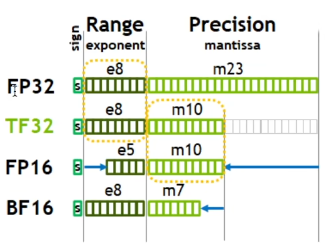

https://www.youtube.com/watch?v=l8pRSuU81PU - 1:28:14 

Andrej explains about TF32, NVidia GPU terms.

In [55]:
"""
# Notably, tensors in the model above are in fp32 (float32) format.
# This is wasteful and slow as it takes a massive byte per tensor. 

# Watch the timing above as Andrej explains.

# TF32 cut off mantissa (precision) bits for faster and more efficient training 
# in exchange for a bit of precision fuzziness.

# Use T32 format by using the following code:
"""
# torch.set_float32_matmul_precision('high')


'\n# Notably, tensors in the model above are in fp32 (float32) format.\n# This is wasteful and slow as it takes a massive byte per tensor. \n\n# Watch the timing above as Andrej explains.\n\n# TF32 cut off mantissa (precision) bits for faster and more efficient training \n# in exchange for a bit of precision fuzziness.\n\n# Use T32 format by using the following code:\n'

In [56]:
# Timing Code
# CPU sent to GPU to do work, but stays idle.
# Timing to stop this bottleneck effect
# torch.cuda.synchronize()

# Expect the first one to be slower due to initialization, buffers etc

In [57]:
#   train_loader = DataLoaderLite(B=4, T=32)

# You can change the B and T to fit for your GPU, the larger the more expensive.
# Use integers that is divisible; to the power of 2: 2^2,3,4,...

In [58]:
def main():
  device = "cpu"
  if torch.cuda.is_available():
      device = "cuda"
  elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
      device = "mps" # Multi-Process Server
  print(f"Using device: {device}")
  
  torch.manual_seed(1337)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)
  
  train_loader = DataLoaderLite(B=4, T=32)
  
  # Use T32 Format
  torch.set_float32_matmul_precision('high')
  
  # Model, get logits
  model = GPT(GPTConfig())
  model.to(device) 
  
  # Optimizer
  optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4) # AdamW is a bug fixed of Adam
  steps = 50
  import time
  for i in range(steps):
    t0 = time.time()
    x, y = train_loader.next_batch()
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    logits, loss = model(x, y)
    loss.backward()
    optimizer.step()
    torch.cuda.synchronize()
    t1 = time.time()
    dt = (t1 - t0)*1000 # Time difference in milliseconds
    tokens_per_sec = (train_loader.B * train_loader.T) / (t1 - t0)
    print(f"Step {i+1}, Loss: {loss.item()}, Dt: {dt:.2f}ms, tok/sec: {tokens_per_sec:.2f}")
    
main()

Using device: cuda
Lines: 40000 | Words: 202651 | Bytes: 1115394
Loaded 338025 tokens.
1 epoch = 2640 batches.
Step 1, Loss: 10.96005916595459, Dt: 56.71ms, tok/sec: 2257.06
Step 2, Loss: 9.687840461730957, Dt: 46.04ms, tok/sec: 2780.26
Step 3, Loss: 9.082446098327637, Dt: 53.68ms, tok/sec: 2384.38
Step 4, Loss: 9.14596939086914, Dt: 40.97ms, tok/sec: 3124.16
Step 5, Loss: 8.626076698303223, Dt: 43.47ms, tok/sec: 2944.60
Step 6, Loss: 8.331666946411133, Dt: 40.60ms, tok/sec: 3153.09
Step 7, Loss: 8.89799690246582, Dt: 46.59ms, tok/sec: 2747.34
Step 8, Loss: 8.837995529174805, Dt: 53.81ms, tok/sec: 2378.95
Step 9, Loss: 8.1160306930542, Dt: 43.13ms, tok/sec: 2967.45
Step 10, Loss: 8.04207992553711, Dt: 55.98ms, tok/sec: 2286.41
Step 11, Loss: 8.380827903747559, Dt: 46.40ms, tok/sec: 2758.80
Step 12, Loss: 7.435524940490723, Dt: 41.93ms, tok/sec: 3052.57
Step 13, Loss: 7.824492454528809, Dt: 55.14ms, tok/sec: 2321.21
Step 14, Loss: 7.458827495574951, Dt: 40.52ms, tok/sec: 3158.66
Step 15

**<u>Important Note: Tokens per seconds is important!</u>**

Note: Not all GPU has T32 format, older ones may not have it.

In [59]:
# Highest setting (F32)
# Step 1, Loss: 10.93676471710205, Dt: 449.78ms, tok/sec: 1138.34

# High setting (T32)
# Step 1, Loss: 10.936789512634277, Dt: 408.58ms, tok/sec: 1253.12

## autocast-Float16, Gradient Scalers, bfloat16, 300ms

Reducing more precision bits.- bfloat16

Note that FP16 reduces Range from `e8` to `e5`, and mantissa to `m10`.
Training in FP16 needs to use <u>Gradient Scaling Operations</u> - extra work - due to reduced range. Hence BFP16 exist which maintains `e8` range but reduce precision (mantissa) from fp32`m23`->tf32/fp16`m10`->`m7` - basically a lower precission tf32 - (Check graph above) 

[Automatic Mixed Precision](https://docs.pytorch.org/tutorials/recipes/recipes/amp_recipe.html#adding-torch-autocast)

[Autocast](https://docs.pytorch.org/docs/stable/amp.html#autocasting)

In [60]:
""" 
https://docs.pytorch.org/tutorials/recipes/recipes/amp_recipe.html#adding-torch-autocast
for epoch in range(0): # 0 epochs, this section is for illustration only
    for input, target in zip(data, targets):
        # Runs the forward pass under ``autocast``.
        with torch.autocast(device_type=device, dtype=torch.float16): # <--------THIS LINE
            output = net(input)
            # output is float16 because linear layers ``autocast`` to float16.
            assert output.dtype is torch.float16

            loss = loss_fn(output, target)
            # loss is float32 because ``mse_loss`` layers ``autocast`` to float32.
            assert loss.dtype is torch.float32

        # Exits ``autocast`` before backward().
        # Backward passes under ``autocast`` are not recommended.
        # Backward ops run in the same ``dtype`` ``autocast`` chose for corresponding forward ops.
        loss.backward()
        opt.step()
        opt.zero_grad() # set_to_none=True here can modestly improve performance

"""

""" 
https://docs.pytorch.org/docs/stable/amp.html#autocasting
- When entering an autocast-enabled region, Tensors may be any type. You should not call half() or bfloat16() on your model(s) or inputs when using autocasting.
- Only surround at forward pass of the model and loss calculation.
"""

' \nhttps://docs.pytorch.org/docs/stable/amp.html#autocasting\n- When entering an autocast-enabled region, Tensors may be any type. You should not call half() or bfloat16() on your model(s) or inputs when using autocasting.\n- Only surround at forward pass of the model and loss calculation.\n'

In [61]:
def main():
  device = "cpu"
  if torch.cuda.is_available():
      device = "cuda"
  elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
      device = "mps" # Multi-Process Server
  print(f"Using device: {device}")
  
  torch.manual_seed(1337)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)
  
  train_loader = DataLoaderLite(B=4, T=32)
  
  # Use T32 Format
  torch.set_float32_matmul_precision('high')
  
  # Model, get logits
  model = GPT(GPTConfig())
  model.to(device) 
  
  # Optimizer
  optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4) # AdamW is a bug fixed of Adam
  steps = 50
  import time
  for i in range(steps):
    t0 = time.time()
    x, y = train_loader.next_batch()
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    with torch.autocast(device_type=device, dtype=torch.bfloat16): # <---- This line
        logits, loss = model(x, y)
        # import code; code.interact(local=locals()) 
        # logits.dtype                          # torch.bfloat16
        # model.transformer.wte
        # model.transformer.wte.weights
        # model.transformer.wte.weights.dtype   # torch.float32
    loss.backward()
    optimizer.step()
    torch.cuda.synchronize()
    t1 = time.time()
    dt = (t1 - t0)*1000 # Time difference in milliseconds
    tokens_per_sec = (train_loader.B * train_loader.T) / (t1 - t0)
    print(f"Step {i+1}, Loss: {loss.item()}, Dt: {dt:.2f}ms, tok/sec: {tokens_per_sec:.2f}")
    
main()

Using device: cuda
Lines: 40000 | Words: 202651 | Bytes: 1115394
Loaded 338025 tokens.
1 epoch = 2640 batches.
Step 1, Loss: 10.95849609375, Dt: 102.90ms, tok/sec: 1243.88
Step 2, Loss: 9.6883544921875, Dt: 48.78ms, tok/sec: 2624.09
Step 3, Loss: 9.085693359375, Dt: 46.99ms, tok/sec: 2724.22
Step 4, Loss: 9.1446533203125, Dt: 46.52ms, tok/sec: 2751.35
Step 5, Loss: 8.62762451171875, Dt: 43.14ms, tok/sec: 2967.42
Step 6, Loss: 8.3333740234375, Dt: 40.77ms, tok/sec: 3139.60
Step 7, Loss: 8.899658203125, Dt: 40.00ms, tok/sec: 3199.79
Step 8, Loss: 8.8380126953125, Dt: 42.86ms, tok/sec: 2986.33
Step 9, Loss: 8.1182861328125, Dt: 49.89ms, tok/sec: 2565.45
Step 10, Loss: 8.0396728515625, Dt: 40.85ms, tok/sec: 3133.33
Step 11, Loss: 8.380126953125, Dt: 48.21ms, tok/sec: 2655.25
Step 12, Loss: 7.4345703125, Dt: 49.43ms, tok/sec: 2589.65
Step 13, Loss: 7.82373046875, Dt: 47.51ms, tok/sec: 2694.03
Step 14, Loss: 7.45843505859375, Dt: 40.84ms, tok/sec: 3133.84
Step 15, Loss: 7.53179931640625, Dt:

## torch.compile - Python overhead, kernel fusion, 130ms

[Explanation by Andrej on Hardware/GPU-Memory/HBM](https://www.youtube.com/watch?v=l8pRSuU81PU&t=1h55m50s)

Tradeoff compilation time with actual timing time - Much faster way of training!

> Speedup mainly comes from reducing Python overhead and GPU read/writes 

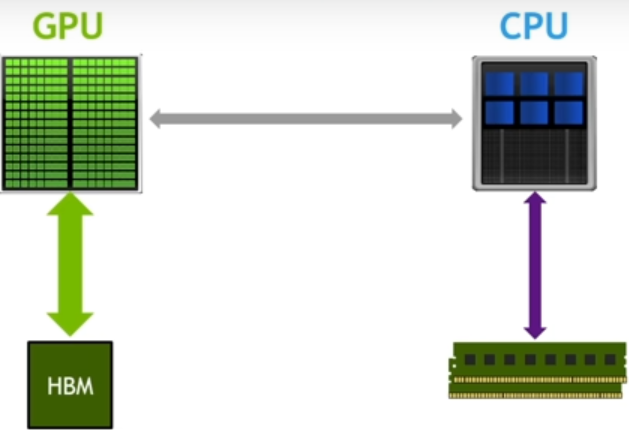

_TL;DR, A TanhGeLU function may require multiple GPU (computer)-HBM (memory) communication per operation. Kernel fusion (torch.compile) make it so that it's only done once, hence faster operation_

In [62]:
def main():
  device = "cpu"
  if torch.cuda.is_available():
      device = "cuda"
  elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
      device = "mps" # Multi-Process Server
  print(f"Using device: {device}")
  
  torch.manual_seed(1337)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)
  
  train_loader = DataLoaderLite(B=4, T=32)
  
  # Use T32 Format
  torch.set_float32_matmul_precision('high')
  
  # Model, get logits
  model = GPT(GPTConfig())
  model.to(device) 
  model = torch.compile(model)
  
  # Optimizer
  optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4) # AdamW is a bug fixed of Adam
  steps = 50
  import time
  for i in range(steps):
    t0 = time.time()
    x, y = train_loader.next_batch()
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    with torch.autocast(device_type=device, dtype=torch.bfloat16): # <---- This line
        logits, loss = model(x, y) 
    loss.backward()
    optimizer.step()
    torch.cuda.synchronize()
    t1 = time.time()
    dt = (t1 - t0)*1000 # Time difference in milliseconds
    tokens_per_sec = (train_loader.B * train_loader.T) / (t1 - t0)
    print(f"Step {i+1}, Loss: {loss.item()}, Dt: {dt:.2f}ms, tok/sec: {tokens_per_sec:.2f}")
    
main()

Using device: cuda
Lines: 40000 | Words: 202651 | Bytes: 1115394
Loaded 338025 tokens.
1 epoch = 2640 batches.
Step 1, Loss: 10.960756301879883, Dt: 2038.40ms, tok/sec: 62.79
Step 2, Loss: 9.687227249145508, Dt: 43.39ms, tok/sec: 2949.99
Step 3, Loss: 9.08315372467041, Dt: 36.05ms, tok/sec: 3550.38
Step 4, Loss: 9.145479202270508, Dt: 35.27ms, tok/sec: 3629.05
Step 5, Loss: 8.627679824829102, Dt: 35.92ms, tok/sec: 3563.91
Step 6, Loss: 8.333356857299805, Dt: 40.83ms, tok/sec: 3135.25
Step 7, Loss: 8.897687911987305, Dt: 35.02ms, tok/sec: 3654.97
Step 8, Loss: 8.837347030639648, Dt: 38.36ms, tok/sec: 3336.80
Step 9, Loss: 8.117093086242676, Dt: 35.64ms, tok/sec: 3591.23
Step 10, Loss: 8.042495727539062, Dt: 42.99ms, tok/sec: 2977.47
Step 11, Loss: 8.380989074707031, Dt: 44.95ms, tok/sec: 2847.67
Step 12, Loss: 7.436327934265137, Dt: 42.80ms, tok/sec: 2990.91
Step 13, Loss: 7.824662685394287, Dt: 47.82ms, tok/sec: 2676.47
Step 14, Loss: 7.460705757141113, Dt: 34.44ms, tok/sec: 3716.45
St

_Editor mini celebration: IT WORKED. WSL2 CAN RUN TRITON WEEEEEEE (Context, 8h of setting up WSL2, Miniconda, Git problems - used SSH)_

_Dt: 39.22ms -> Dt: 34.09ms._ Triton compile's effect is more visible on larger architectures, and use of Tensor Core GPU as seen in video. 

In [63]:
# > W0610 11:53:34.500000 15668 site-packages/torch/_inductor/utils.py:1250] [0/0] Not enough SMs to use max_autotune_gemm mode
# The check:
import torch
import warnings

gpu_ok = False
if torch.cuda.is_available():
    device_cap = torch.cuda.get_device_capability()
    if device_cap in ((7, 0), (8, 0), (9, 0)):
        gpu_ok = True

if not gpu_ok:
    warnings.warn(
        "GPU is not NVIDIA V100, A100, or H100. Speedup numbers may be lower "
        "than expected."
    )

/tmp/ipykernel_11973/2941613373.py:13: UserWarning: GPU is not NVIDIA V100, A100, or H100. Speedup numbers may be lower than expected.
  warnings.warn(


## Flash Attention

There are some operations that torch.compile does not find and optimize, flash attention for example.

[Online Normalizer calculation for Softmax](https://arxiv.org/pdf/1805.02867)

[Flash Attention paper](https://arxiv.org/pdf/2205.14135)

[Flash Attention paper 2](https://arxiv.org/pdf/2307.08691)
- It is an algorithm that improve efficiency in performing attention.
- Flash Attention is another kernel fusion operation (reducing attention part)
- It is a kernel fusion that `torch.compile` could not find
    - because it requires an algorithmic rewrite of how attention is implemented.
- Flash attention does more flops than the old attention implementation
    - but it is significantly faster (paper cited 7.6x potentially)
    - because of it is implemented with memory hierarchy in mind (check video from torch.compile)
    - fewer reads and writes to high bandwidth memory;
    - More flops but avoid load and store to HBM 
- <u>Flash Attention is designed to not materialize some very large matrixes (where all the k,q,v interact)</u>
    - Very large matrix: For each head, for each batch element, t x t matrix.
- The trick is <u>**Online Softmax**</u> from Online normalizer paper.
    - Evaluate softmax incrementally without realizing input to softmax to do normalization.

### Online normalization for Softmax

Generated by Qwen2.5-7b-instruct:

**Problem Statement**

The softmax function for a vector $\mathbf{z} = [z_1, z_2, \dots, z_n]$ is defined as:

$\text{softmax}(z_i) = \frac{\exp(z_i)}{\sum_{j=1}^n \exp(z_j)}$

Paper:
$\text{y} = \text{Softmax(x)} = \text{yi}  = \frac{\exp(x_i)}{\sum_{j=1}^V \exp(x_j)}$

The main challenge is to compute the numerator and denominator in a numerically stable way without causing overflow or underflow.

**Online Normalization Techniques**

Several techniques have been proposed to perform this calculation efficiently:

- 1. **Log-Sum-Exp Trick**
This technique involves computing the log-sum-exp of the input vector, which helps avoid direct computation of large exponentials and potential overflows. Here’s how it works:

   - 1. **Compute the Maximum Value**: First, compute the maximum value in the vector $\mathbf{z}$:

         $M = \max(z_1, z_2, \dots, z_n)$
   
   - 2. **Normalize Using Shifted Values**: Compute the exponentials of shifted values:

         $e_i = \exp(z_i - M)$
  
   - 3. **Compute Log-Sum-Exp**: Compute the log-sum-exp of these shifted values:

         $LSE = \log\left( \sum_{j=1}^n e_j \right)$

   - 4. **Compute Softmax Values**: The softmax value for each element is then given by:

         $\text{softmax}(z_i) = \frac{\exp(z_i - M)}{\exp(LSE)}$
   

This approach ensures that the largest exponent used in the computation is $z_i - M $, which helps keep the numbers within a manageable range and prevents overflow.

- 2. **Online Log-Sum-Exp Calculation**
For an online setting, where new values are added over time, you can maintain running estimates of the log-sum-exp:

   - 1. **Initialize**:Start with $LSE = -\infty$.
   - 2. **Update for Each New Value**: When a new value $z_i$ is added:
      - Compute $M_i = \max(M, z_i)$.
      - Update the shifted value: $e_i = \exp(z_i - M_i)$.
      - Update the running log-sum-exp:

        $LSE_{\text{new}} = \log(e_i + \exp(LSE - M_i))$

   - 3. **Compute Softmax**: The softmax value for each element is then given by:

        $\text{softmax}(z_i) = \frac{\exp(z_i - M)}{\exp(LSE)}$

- 3. **Batched Online Normalization**
If you have a batch of vectors and want to compute the softmax online, you can maintain separate running estimates for each vector in the batch:

   - 1. **Initialize**: For each vector $z^{(b)}$ in the batch, initialize $LSE^{(b)} = -\infty$.

   - 2. **Update for Each New Value**: When a new value $z_i^{(b)}$ is added to vector $b$:
      - Compute $M_i^{(b)} = \max(M^{(b)}, z_i^{(b)})$.
      - Update the shifted value: $e_i^{(b)} = \exp(z_i^{(b)} - M_i^{(b)})$.
      - Update the running log-sum-exp for vector $b$:

        $LSE_{\text{new}}^{(b)} = \log(e_i^{(b)} + \exp(LSE^{(b)} - M_i^{(b)}))$

   - 3. **Compute Softmax**: The softmax value for each element in vector \( b \) is then given by:

         $\text{softmax}(z_i^{(b)}) = \frac{\exp(z_i^{(b)} - M^{(b)})}{\exp(LSE^{(b)})}$

**Summary**
- **Log-Sum-Exp Trick**: Helps avoid overflow and underflow by shifting values.
- **Online Log-Sum-Exp Calculation**: Maintains running estimates for efficient updates in an online setting.
- **Batched Online Normalization**: Extends the technique to handle multiple vectors efficiently.

These techniques ensure that softmax can be computed numerically stably even in real-time or batch processing scenarios.

### Flash Attention

Flash attention is a technique used in transformer-based models, particularly in large-scale language models like those developed by Alibaba Cloud (such as M6 and TUNA). It was introduced to address the computational challenges associated with computing full softmax for long sequences. Flash attention aims to make multi-head attention more efficient by using a block-wise approach to parallelize the computation of attention scores.

Here's how flash attention works:

- Key Concepts
    1. **Block-wise Processing**: Instead of attending to all tokens at once, flash attention processes tokens in blocks. Each block is small enough that computing the attention scores for the entire block can be done efficiently using a kernel or algorithm like CUDA primitives on GPUs.
    2. **Efficient Parallelization**: By processing tokens in smaller blocks, flash attention allows for better parallelism. This is particularly beneficial because the computation of attention scores for each token pair within a block can often be computed independently and thus can be executed in parallel.
    3. **Use of Kernels**: Flash attention leverages optimized GPU kernels to compute the attention scores for each small block. These kernels are designed to take advantage of the parallel architecture of GPUs, leading to significant speedups compared to traditional methods.

- Steps Involved

    1. **Token Blocking**: Divide the input sequence into smaller blocks. The size of these blocks can be adjusted based on the available GPU memory and computational resources.

    2. **Compute Attention Scores**: For each block, compute the attention scores using a parallel kernel. This step involves computing the dot products between the query vectors and key vectors for all pairs within the block.

    3. **Apply Softmax**: Apply softmax to the computed attention scores to get normalized probabilities. This is usually done in a parallelized manner across blocks as well.

    4. **Compute Contextual Embeddings**: Finally, use the softmax probabilities to compute the weighted sum of value vectors, which gives the contextual embeddings for each block.

    5. **Combine Results**: Once all blocks are processed, combine the results from each block to form the final output sequence or hidden states.

- Advantages
    - **Efficiency**: By processing tokens in smaller blocks, flash attention reduces memory usage and allows better parallelization on GPUs.
    - **Scalability**: This technique can be scaled up for very large models by increasing the size of the blocks while ensuring that the computational resources (like GPU memory) are sufficient.

- Challenges
    - **Precision Loss**: The use of block-wise processing might introduce some precision loss if not handled carefully. Ensuring numerical stability is crucial.
    - **Overhead**: There can be overhead associated with managing and dividing tokens into blocks, which needs to be optimized for performance gains.

In summary, flash attention is a technique that enhances the efficiency of multi-head attention in large-scale transformer models by processing tokens in smaller blocks, thereby leveraging parallel computing resources more effectively.

### Code update

In [64]:
# It all comes down to this
# y = F.scaled_dot_product_attention(q, k, v, is_causal=True)

In [65]:
# class CausalSelfAttention(nn.Module):
# Remove the 4 attention lines
# GPT2: scale down at c_proj
class CausalSelfAttention(nn.Module):
  # Multi-Headed Attention

  def __init__(self, config):
    super().__init__()
    assert config.n_embd % config.n_head == 0
    # Key, Query, Value projections for all heads, but in a batch
    self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
    # Output projection
    self.c_proj = nn.Linear(config.n_embd, config.n_embd)
    self.c_proj.NANOGPT_SCALE_INIT = 1 # Flag for scaling init 
    
    # Regularization
    self.n_head = config.n_head
    self.n_embd = config.n_embd
    # Not really a "bias", closer to a mask
    # Following OpenAI/HF naming
    self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                  .view(1, 1, config.block_size, config.block_size))

  def forward(self, x):
    # Batch size, sequence length, embedding dimensionality(n_embd)
    B, T, C = x.size()
    # Calculate Key, Query, Value for all heads in batch
    # and move head forward to be batch
    # nh is "Number of heads", hs is "head size", C (number of channels) = nh * ns
    # E.g. GPT-2 (124M), n_heads=12, hs=64, so nh*hs=C=768 channels in Transformer
    qkv = self.c_attn(x)
    q, k, v = qkv.split(self.n_embd, dim=2)
    k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
    q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
    v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
    
    # New: Flash Attention: Remove these
    # Attention (materializes the large (T, T) matrix for all the queries and keys)
    # att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
    # att = att.masked_fill(self.bias[:,:,:T,:T]==0, float('-inf')) # Consider tokens before, not after it
    # att = F.softmax(att, dim=-1) # Sum = 1
    # y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
    y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
    
    y = y.transpose(1, 2).contiguous().view(B, T, C) # Re-assemble all head outputs side by side
    # Output projection
    y = self.c_proj(y)
    return y

### For folding - ignore

In [66]:
class Block(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.ln_1 = nn.LayerNorm(config.n_embd)
    self.attn = CausalSelfAttention(config) # Reduction
    self.ln_2 = nn.LayerNorm(config.n_embd)
    self.mlp = MLP(config) # Mapping

  def forward(self, x):
    # Residual channel preferably clean
    # from supervision to token input.
    # Gradient flow without normalization in between.
    # From optimization perspective.
    # This is pre-normalization layer. Feed-Forward Network.
    x = x + self.attn(self.ln_1(x))
    x = x + self.mlp(self.ln_2(x))
    # Layer Norm is after Attention
    return x

@dataclass
class GPTConfig:
  block_size: int = 1024 # Max sequence length
  vocab_size: int = 50257 # No. tokens: 50,000 BPE merges + 256 bytes tokens + 1 <|endoftext|>
  n_layer: int = 12 # Number of layers
  n_head: int = 12 # Number of heads
  n_embd: int = 768 # Embedding dimensions

class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

    self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd), # Output Embedding
        wpe = nn.Embedding(config.block_size, config.n_embd), # Positional Embedding
        # As seen in the pretrained, h layers can be indexed to create 12 layers
        h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]), # Nx in image
        ln_f = nn.LayerNorm(config.n_embd),
    ))
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
    
    # Weight Sharing Scheme
    self.transformer.wte.weight = self.lm_head.weight
    
    # Init param
    self.apply(self._init_weights)
    
  def _init_weights(self, module):
    if isinstance(module, nn.Linear):
        std = 0.02
        if hasattr(module, 'NANOGPT_SCALE_INIT'):
            std *= (2 * self.config.n_layer) ** -0.5
        # Note: that std=0.02 because d_head in GPT2 roughly results the same - Check back to initialization notebook
        torch.nn.init.normal_(module.weight, mean=0.0, std=std) 
        if module.bias is not None:
            torch.nn.init.zeros_(module.bias) # module.bias is defaulted at uniform, not zero
    elif isinstance(module, nn.Embedding):
        torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

  @classmethod
  def from_pretrained(cls, model_type):
    """ Loads pretrained GPT-2 model weights from HuggingFace """
    assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
    from transformers import GPT2LMHeadModel
    print("loading weights from pretrained gpt: %s" % model_type)

    # n_layer, n_head and n_embd are determined from model_type
    config_args = {
        'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
        'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
        'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
        'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
    }[model_type]
    config_args['vocab_size'] = 50257 # Always 50257 for GPT model checkpoints
    config_args['block_size'] = 1024 # Always 1024 for GPT model checkpoints
    # Create a from-scratch initialized minGPT model
    config = GPTConfig(**config_args)
    model = GPT(config)
    sd = model.state_dict()
    sd_keys = sd.keys()
    sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # Discard this mask / buffer, not a param

    # Init a huggingface/transformers model
    model_hf = GPT2LMHeadModel.from_pretrained(model_type)
    sd_hf = model_hf.state_dict()

    # Copy while ensuring all of the parameters are aligned and match in names and shapes
    sd_keys_hf = sd_hf.keys()
    sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # Ignore, just a buffer
    sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # Ignore, just the mask (buffer)
    transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
    # Basically OpenAI checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear.
    # This means that we have to transpose these weights when we import them.
    assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
    for k in sd_keys_hf:
        if any(k.endswith(w) for w in transposed):
            # Special treatment for the Conv1D weights we need to transpose
            assert sd_hf[k].shape[::-1] == sd[k].shape
            with torch.no_grad():
                sd[k].copy_(sd_hf[k].t())
        else:
            # Vanilla copy over the other parameters
            assert sd_hf[k].shape == sd[k].shape
            with torch.no_grad():
                sd[k].copy_(sd_hf[k])

    return model 

  def forward(self, idx, targets=None):
    # idx is of shape (B, T)
    B, T = idx.size()
    assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
    # Forward the token and posisition embeddings
    pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
    pos_emb = self.transformer.wpe(pos) # Position embeddings of shape (T, n_embd)
    tok_emb = self.transformer.wte(idx) # Token embeddings of shape (B, T, n_embd)
    x = tok_emb + pos_emb # Broadcasting happening here
    # Forward the blocks of the transformer
    for block in self.transformer.h:
        x = block(x)
    # Forward the final layernorm and the classifier
    x = self.transformer.ln_f(x)
    logits = self.lm_head(x) # (B, T, vocab_size)
    loss = None
    if targets is not None:
      loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1)) # NOTE: cross-entropy uses 2-D
    return logits, loss


def main():
  device = "cpu"
  if torch.cuda.is_available():
      device = "cuda"
  elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
      device = "mps" # Multi-Process Server
  print(f"Using device: {device}")
  
  torch.manual_seed(1337)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)
  
  # Dataset  
  train_loader = DataLoaderLite(B=16, T=32)
  
  # Use T32 Format
  torch.set_float32_matmul_precision('high')
  
  # Model, get logits
  model = GPT(GPTConfig())
  model.to(device) 
  model = torch.compile(model)
  
  # Optimizer
  optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4) # AdamW is a bug fixed of Adam
  steps = 50
  import time
  for i in range(steps):
    t0 = time.time()
    x, y = train_loader.next_batch()
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    with torch.autocast(device_type=device, dtype=torch.bfloat16): # <---- This line
        logits, loss = model(x, y) 
    loss.backward()
    optimizer.step()
    torch.cuda.synchronize()
    t1 = time.time()
    dt = (t1 - t0)*1000 # Time difference in milliseconds
    tokens_per_sec = (train_loader.B * train_loader.T) / (t1 - t0)
    print(f"Step {i+1}, Loss: {loss.item()}, Dt: {dt:.2f}ms, tok/sec: {tokens_per_sec:.2f}")
      
main()

Using device: cuda
Lines: 40000 | Words: 202651 | Bytes: 1115394
Loaded 338025 tokens.
1 epoch = 660 batches.
Step 1, Loss: 10.937524795532227, Dt: 1229.75ms, tok/sec: 416.34
Step 2, Loss: 9.587305068969727, Dt: 129.76ms, tok/sec: 3945.76
Step 3, Loss: 9.02421760559082, Dt: 79.35ms, tok/sec: 6452.27
Step 4, Loss: 8.776220321655273, Dt: 134.71ms, tok/sec: 3800.65
Step 5, Loss: 8.899796485900879, Dt: 112.06ms, tok/sec: 4568.78
Step 6, Loss: 8.494985580444336, Dt: 94.37ms, tok/sec: 5425.64
Step 7, Loss: 8.193523406982422, Dt: 93.45ms, tok/sec: 5479.02
Step 8, Loss: 8.259427070617676, Dt: 98.62ms, tok/sec: 5191.54
Step 9, Loss: 8.367652893066406, Dt: 108.24ms, tok/sec: 4730.10
Step 10, Loss: 8.243725776672363, Dt: 134.34ms, tok/sec: 3811.24
Step 11, Loss: 7.873889923095703, Dt: 121.23ms, tok/sec: 4223.55
Step 12, Loss: 7.366121292114258, Dt: 113.68ms, tok/sec: 4503.85
Step 13, Loss: 7.575413703918457, Dt: 113.08ms, tok/sec: 4527.81
Step 14, Loss: 7.128266334533691, Dt: 117.97ms, tok/sec: 4

### Result

In [67]:
# torch.compile (Pre-flash attention) 
# 1 epoch = 2640 batches.
# W0610 11:53:34.500000 15668 site-packages/torch/_inductor/utils.py:1250] [0/0] Not enough SMs to use max_autotune_gemm mode
# Step 1, Loss: 10.960756301879883, Dt: 19553.78ms, tok/sec: 6.55
# Step 2, Loss: 9.687227249145508, Dt: 31.20ms, tok/sec: 4102.45
# Step 50, Loss: 6.801275253295898, Dt: 34.09ms, tok/sec: 3755.18

# flash attention 
# 1 epoch = 660 batches.
# Step 1, Loss: 10.937524795532227, Dt: 861.04ms, tok/sec: 594.63
# Step 2, Loss: 9.587305068969727, Dt: 55.70ms, tok/sec: 9191.93
# Step 50, Loss: 6.083582878112793, Dt: 50.81ms, tok/sec: 10076.78

# py version 
# 1 epoch = 660 batches.
# Step 1, Loss: 10.937524795532227, Dt: 1321.46ms, tok/sec: 387.45
# Step 2, Loss: 9.587305068969727, Dt: 54.23ms, tok/sec: 9441.36
# Step 50, Loss: 6.099874496459961, Dt: 43.18ms, tok/sec: 11855.97


# No error O.O. Slightly slower, I am not using mega GPU and big architecture, 
# check Andrej's video for stat accuracy.

## Optimization by 2^ numbers (nice numbers)

This is dumb looking optimization compared to the others but it works.

In [68]:
# Original vocab_size = 50257
# model = GPT(GPTConfig(vocab_size=50304))

In [69]:
def main():
  device = "cpu"
  if torch.cuda.is_available():
      device = "cuda"
  elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
      device = "mps" # Multi-Process Server
  print(f"Using device: {device}")
  
  torch.manual_seed(1337)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)
  
  # Dataset  
  train_loader = DataLoaderLite(B=16, T=32)
  
  # Use T32 Format
  torch.set_float32_matmul_precision('high')
  
  # Model, get logits
  model = GPT(GPTConfig(vocab_size=50304))
  model.to(device) 
  model = torch.compile(model)
  
  # Optimizer
  optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4) # AdamW is a bug fixed of Adam
  steps = 50
  import time
  for i in range(steps):
    t0 = time.time()
    x, y = train_loader.next_batch()
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    with torch.autocast(device_type=device, dtype=torch.bfloat16): # <---- This line
        logits, loss = model(x, y) 
    loss.backward()
    optimizer.step()
    torch.cuda.synchronize()
    t1 = time.time()
    dt = (t1 - t0)*1000 # Time difference in milliseconds
    tokens_per_sec = (train_loader.B * train_loader.T) / (t1 - t0)
    print(f"Step {i+1}, Loss: {loss.item()}, Dt: {dt:.2f}ms, tok/sec: {tokens_per_sec:.2f}")
      
main()

Using device: cuda
Lines: 40000 | Words: 202651 | Bytes: 1115394
Loaded 338025 tokens.
1 epoch = 660 batches.
Step 1, Loss: 10.93133544921875, Dt: 1048.02ms, tok/sec: 488.54
Step 2, Loss: 9.603887557983398, Dt: 57.40ms, tok/sec: 8920.27
Step 3, Loss: 8.904552459716797, Dt: 62.34ms, tok/sec: 8212.71
Step 4, Loss: 8.818501472473145, Dt: 53.26ms, tok/sec: 9613.59
Step 5, Loss: 8.86669921875, Dt: 64.72ms, tok/sec: 7910.46
Step 6, Loss: 8.464088439941406, Dt: 57.22ms, tok/sec: 8948.52
Step 7, Loss: 8.140578269958496, Dt: 55.51ms, tok/sec: 9223.60
Step 8, Loss: 8.280233383178711, Dt: 63.76ms, tok/sec: 8030.62
Step 9, Loss: 8.390982627868652, Dt: 54.79ms, tok/sec: 9344.69
Step 10, Loss: 8.22048568725586, Dt: 53.20ms, tok/sec: 9623.58
Step 11, Loss: 7.85123348236084, Dt: 62.76ms, tok/sec: 8158.54
Step 12, Loss: 7.347710609436035, Dt: 56.90ms, tok/sec: 8998.54
Step 13, Loss: 7.578856468200684, Dt: 53.36ms, tok/sec: 9594.73
Step 14, Loss: 7.114462852478027, Dt: 52.90ms, tok/sec: 9677.88
Step 15,

In [70]:
# jupyter version
# W0610 16:14:40.921000 68611 site-packages/torch/_inductor/utils.py:1250] [1/1] Not enough SMs to use max_autotune_gemm mode
# Step 1, Loss: 10.93133544921875, Dt: 12299.18ms, tok/sec: 41.63
# Step 2, Loss: 9.603887557983398, Dt: 47.16ms, tok/sec: 10857.06
# Step 50, Loss: 5.977965354919434, Dt: 47.92ms, tok/sec: 10683.52

# py version
# Step 1, Loss: 10.93133544921875, Dt: 1407.36ms, tok/sec: 363.80
# Step 2, Loss: 9.603887557983398, Dt: 57.10ms, tok/sec: 8967.32
# Step 50, Loss: 5.977965354919434, Dt: 47.92ms, tok/sec: 10683.52

# Section 3: Hyperparameters, AdamW, Gradient Clipping

## LR Schedler, Warmup + Cosine Decay

GPT3 paper
> B Details of Model Training  
To train all versions of GPT-3, we use Adam with $β1 = 0.9$, $β2 = 0.95$, and $\epsilon = 10−8$, 


In [71]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), eps=1e-8)

> we clip the global norm of the gradient at 1.0, 

In [72]:
norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
# Calculate global norm of the parameters, square and add it all up, then sqrt it
# and gradient is no more than 1.0.

# This is used because 
# during optimization, you may get high loss (maybe due to bad data batch or unlucky)
# which can cause a shock to the model.
# Clip it to prevent loss from going too big.

# This can be visualized o get a good idea of how the model is going.

In [73]:
def main():
  device = "cpu"
  if torch.cuda.is_available():
      device = "cuda"
  elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
      device = "mps" # Multi-Process Server
  print(f"Using device: {device}")
  
  torch.manual_seed(1337)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)
  
  # Dataset  
  train_loader = DataLoaderLite(B=16, T=32)
  
  # Use T32 Format
  torch.set_float32_matmul_precision('high')
  
  # Model, get logits
  model = GPT(GPTConfig(vocab_size=50304))
  model.to(device) 
  model = torch.compile(model)
  
  # Optimizer
  optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), eps=1e-8)  
  steps = 50
  import time
  for i in range(steps):
    t0 = time.time()
    x, y = train_loader.next_batch()
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    with torch.autocast(device_type=device, dtype=torch.bfloat16): # <---- This line
        logits, loss = model(x, y) 
    loss.backward()
    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    torch.cuda.synchronize()
    t1 = time.time()
    dt = (t1 - t0)*1000 # Time difference in milliseconds
    tokens_per_sec = (train_loader.B * train_loader.T) / (t1 - t0)
    print(f"Step {i+1} | Loss: {loss.item()} | Norm: {norm:.4f} | Dt: {dt:.2f}ms | tok/sec: {tokens_per_sec:.2f}")
      
main()

Using device: cuda
Lines: 40000 | Words: 202651 | Bytes: 1115394
Loaded 338025 tokens.
1 epoch = 660 batches.
Step 1 | Loss: 10.93133544921875 | Norm: 32.3039 | Dt: 63.79ms | tok/sec: 8026.21
Step 2 | Loss: 9.604369163513184 | Norm: 6.1564 | Dt: 70.63ms | tok/sec: 7248.94
Step 3 | Loss: 8.980461120605469 | Norm: 4.6681 | Dt: 59.82ms | tok/sec: 8558.88
Step 4 | Loss: 9.056795120239258 | Norm: 7.8646 | Dt: 57.77ms | tok/sec: 8862.44
Step 5 | Loss: 8.888660430908203 | Norm: 2.5205 | Dt: 58.90ms | tok/sec: 8693.14
Step 6 | Loss: 8.50235652923584 | Norm: 3.3475 | Dt: 69.20ms | tok/sec: 7398.76
Step 7 | Loss: 8.204002380371094 | Norm: 3.8359 | Dt: 69.71ms | tok/sec: 7344.26
Step 8 | Loss: 8.270475387573242 | Norm: 2.1039 | Dt: 64.63ms | tok/sec: 7921.75
Step 9 | Loss: 8.393577575683594 | Norm: 2.5051 | Dt: 60.57ms | tok/sec: 8452.83
Step 10 | Loss: 8.238419532775879 | Norm: 2.5934 | Dt: 73.59ms | tok/sec: 6957.03
Step 11 | Loss: 7.84535551071167 | Norm: 2.2371 | Dt: 61.22ms | tok/sec: 8362.8

> and we use cosine decay for learning rate down to 10% of its value, over 260 billion tokens (after 260
billion tokens, training continues at 10% of the original learning rate).

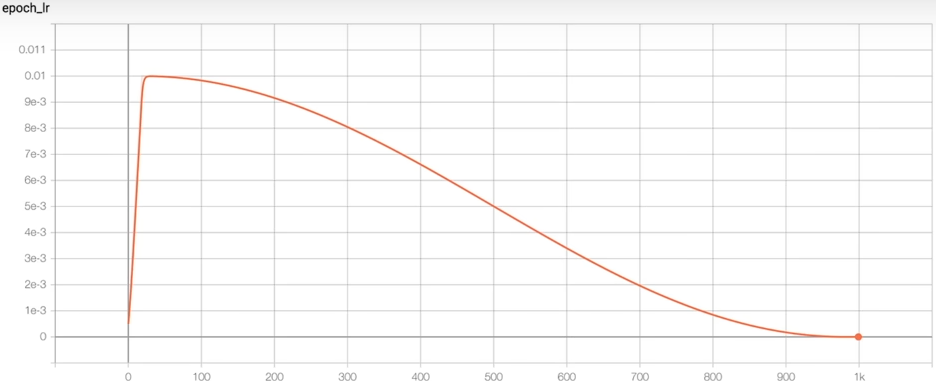

Image source from video

> There is a linear LR warmup over the first 375 million tokens.  

In [74]:
def main():
  device = "cpu"
  if torch.cuda.is_available():
      device = "cuda"
  elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
      device = "mps" # Multi-Process Server
  print(f"Using device: {device}")
  
  torch.manual_seed(1337)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)
  
  # Dataset  
  train_loader = DataLoaderLite(B=16, T=32)
  
  # Use T32 Format
  torch.set_float32_matmul_precision('high')
  
  # Model, get logits
  model = GPT(GPTConfig(vocab_size=50304))
  model.to(device) 
  model = torch.compile(model)
  
  # Optimizer
  optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), eps=1e-8)  
  max_lr = 3e-4
  min_lr = max_lr * 0.1
  warmup_steps = 10
  max_steps = 50
  
  # Scheduler
  def get_lr(it):
      # 1) Linear warmup for warmup_iters steps
      if it < warmup_steps:
          return max_lr * (it+1) / warmup_steps
      # 2) If it > lr_decay_iters, return min learning rate
      if it > max_steps:
          return min_lr
      # 3) In between, use cosine decay don to min learning rate
      decay_ratio = (it - warmup_steps) / (max_steps - warmup_steps)
      assert 0 <= decay_ratio <= 1
      coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio)) # Coeff starts at 1 and goes to 0
      return min_lr + coeff * (max_lr - min_lr)
  # NOTE: Pytorch also has a scheduler
  
  import time
  for step in range(max_steps):
    t0 = time.time()
    x, y = train_loader.next_batch()
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    with torch.autocast(device_type=device, dtype=torch.bfloat16): # <---- This line
        logits, loss = model(x, y) 
    loss.backward()
    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    
    # Update learning rate
    lr = get_lr(step)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    
    optimizer.step()
    torch.cuda.synchronize()
    t1 = time.time()
    dt = (t1 - t0)*1000 # Time difference in milliseconds
    tokens_per_sec = (train_loader.B * train_loader.T) / (t1 - t0)
    print(f"Step {step+1:4d} | Loss: {loss.item():.6f} | LR: {lr:.4e} | Norm: {norm:.4f} | Dt: {dt:.2f}ms | tok/sec: {tokens_per_sec:.2f}")
      
main()

Using device: cuda
Lines: 40000 | Words: 202651 | Bytes: 1115394
Loaded 338025 tokens.
1 epoch = 660 batches.
Step    1 | Loss: 10.931335 | LR: 3.0000e-05 | Norm: 32.3039 | Dt: 79.70ms | tok/sec: 6423.82
Step    2 | Loss: 9.844017 | LR: 6.0000e-05 | Norm: 14.1339 | Dt: 71.66ms | tok/sec: 7144.42
Step    3 | Loss: 9.188366 | LR: 9.0000e-05 | Norm: 10.1242 | Dt: 79.66ms | tok/sec: 6427.22
Step    4 | Loss: 9.408901 | LR: 1.2000e-04 | Norm: 9.0891 | Dt: 69.81ms | tok/sec: 7333.83
Step    5 | Loss: 9.307983 | LR: 1.5000e-04 | Norm: 4.9509 | Dt: 70.67ms | tok/sec: 7245.32
Step    6 | Loss: 8.825892 | LR: 1.8000e-04 | Norm: 3.0374 | Dt: 74.43ms | tok/sec: 6878.62
Step    7 | Loss: 8.516849 | LR: 2.1000e-04 | Norm: 2.9393 | Dt: 82.02ms | tok/sec: 6242.09
Step    8 | Loss: 8.742855 | LR: 2.4000e-04 | Norm: 2.7485 | Dt: 83.23ms | tok/sec: 6151.80
Step    9 | Loss: 8.858534 | LR: 2.7000e-04 | Norm: 2.7198 | Dt: 77.62ms | tok/sec: 6595.89
Step   10 | Loss: 8.631037 | LR: 3.0000e-04 | Norm: 2.5952

<u>In paper</u>
> Data are sampled without replacement during training (until an epoch boundary is reached) to minimize overfitting. 

Basically any sequence used in this epoch will be removed from the matrix until the next epoch - no repeat.

<u>In paper. But the following is skipped code-wise,</u>


> We also gradually increase the batch size linearly from a small value (32k tokens) to the full value over the first 4-12 billion tokens of training, depending on the model size. 

This will complicate the arithmatic due to changing number of tokens. This is also not an algorithmic optimization, more of a system-speed improvement -Andrej

## Batch size scheduler, Weight Decay, FusedAdamW, 90ms

<u>In paper. Regularization.</u>
> All models use weight decay of 0.1 to provide a small amount of regularization [LH17].

In [75]:
# optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), eps=1e-8)  

# optimizer = model.configure_optimizers(weight_decay=0.1, learning_rate=6e-4, device=device) 

In [76]:
class GPT(nn.Module):

  def __init__(self, config):
    super().__init__()
    self.config = config

    self.transformer = nn.ModuleDict(dict(
        wte = nn.Embedding(config.vocab_size, config.n_embd), # Output Embedding
        wpe = nn.Embedding(config.block_size, config.n_embd), # Positional Embedding
        # As seen in the pretrained, h layers can be indexed to create 12 layers
        h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]), # Nx in image
        ln_f = nn.LayerNorm(config.n_embd),
    ))
    self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
    
    # Weight Sharing Scheme
    self.transformer.wte.weight = self.lm_head.weight
    
    # Init param
    self.apply(self._init_weights)
    
  def _init_weights(self, module):
    if isinstance(module, nn.Linear):
        std = 0.02
        if hasattr(module, 'NANOGPT_SCALE_INIT'):
            std *= (2 * self.config.n_layer) ** -0.5
        # Note: that std=0.02 because d_head in GPT2 roughly results the same - Check back to initialization notebook
        torch.nn.init.normal_(module.weight, mean=0.0, std=std) 
        if module.bias is not None:
            torch.nn.init.zeros_(module.bias) # module.bias is defaulted at uniform, not zero
    elif isinstance(module, nn.Embedding):
        torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

  @classmethod
  def from_pretrained(cls, model_type):
    """ Loads pretrained GPT-2 model weights from HuggingFace """
    assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
    from transformers import GPT2LMHeadModel
    print("loading weights from pretrained gpt: %s" % model_type)

    # n_layer, n_head and n_embd are determined from model_type
    config_args = {
        'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
        'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
        'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
        'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
    }[model_type]
    config_args['vocab_size'] = 50257 # Always 50257 for GPT model checkpoints
    config_args['block_size'] = 1024 # Always 1024 for GPT model checkpoints
    # Create a from-scratch initialized minGPT model
    config = GPTConfig(**config_args)
    model = GPT(config)
    sd = model.state_dict()
    sd_keys = sd.keys()
    sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # Discard this mask / buffer, not a param

    # Init a huggingface/transformers model
    model_hf = GPT2LMHeadModel.from_pretrained(model_type)
    sd_hf = model_hf.state_dict()

    # Copy while ensuring all of the parameters are aligned and match in names and shapes
    sd_keys_hf = sd_hf.keys()
    sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # Ignore, just a buffer
    sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # Ignore, just the mask (buffer)
    transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
    # Basically OpenAI checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear.
    # This means that we have to transpose these weights when we import them.
    assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
    for k in sd_keys_hf:
        if any(k.endswith(w) for w in transposed):
            # Special treatment for the Conv1D weights we need to transpose
            assert sd_hf[k].shape[::-1] == sd[k].shape
            with torch.no_grad():
                sd[k].copy_(sd_hf[k].t())
        else:
            # Vanilla copy over the other parameters
            assert sd_hf[k].shape == sd[k].shape
            with torch.no_grad():
                sd[k].copy_(sd_hf[k])

    return model
  
  def configure_optimizers(self, weight_decay, learning_rate, device):
    # Start with all of the candidate parameters (that require grad)
    param_dict = {pn: p for pn, p in self.named_parameters()}
    param_dict = {pn: p for pn, p in param_dict.items() if p.requires_grad}
    
    # Create optim groups. Any parameters that is 2D will be weight decayed, otherwise no.
    # i.e. All weight tensors in matmuls + embeddings decay, all biases and layernorms don't.
    # Decay 2D tensors: Embeddings and matrices that participate in linear (matmul)
    # Don't decay 1D tensors: Biases, LayerNorms, Scales).
    decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
    nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]
    optim_groups = [
      {'params': decay_params, 'weight_decay': weight_decay},
      {'params': nodecay_params, 'weight_decay': 0.0},
    ]
    
    num_decay_params = sum(p.numel() for p in decay_params)
    num_nodecay_params = sum(p.numel() for p in nodecay_params)
    print(f"Num decayed parameter tensors: {len(decay_params)}, with {num_decay_params:,} parameterss")
    print(f"Num non-decayed parameter tensors: {len(nodecay_params)}, with {num_nodecay_params:,} parameters")

    # Create AdamW optimizer and use the fused version if it is available
    import inspect
    fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
    use_fused = fused_available and 'cuda' in device
    print(f"Using fused AdamW: {use_fused}")
    optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=(0.9, 0.95), eps=1e-8, fused=use_fused)
    return optimizer

  def forward(self, idx, targets=None):
    # idx is of shape (B, T)
    B, T = idx.size()
    assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
    # Forward the token and posisition embeddings
    pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
    pos_emb = self.transformer.wpe(pos) # Position embeddings of shape (T, n_embd)
    tok_emb = self.transformer.wte(idx) # Token embeddings of shape (B, T, n_embd)
    x = tok_emb + pos_emb # Broadcasting happening here
    # Forward the blocks of the transformer
    for block in self.transformer.h:
        x = block(x)
    # Forward the final layernorm and the classifier
    x = self.transformer.ln_f(x)
    logits = self.lm_head(x) # (B, T, vocab_size)
    loss = None
    if targets is not None:
      loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1)) # NOTE: cross-entropy uses 2-D
    return logits, loss

In [77]:
def main():
  device = "cpu"
  if torch.cuda.is_available():
      device = "cuda"
  elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
      device = "mps" # Multi-Process Server
  print(f"Using device: {device}")
  
  torch.manual_seed(1337)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)
  
  # Dataset  
  train_loader = DataLoaderLite(B=16, T=32)
  
  # Use T32 Format
  torch.set_float32_matmul_precision('high')
  
  # Model, get logits
  model = GPT(GPTConfig(vocab_size=50304))
  model.to(device) 
  model = torch.compile(model)
  
  # Optimizer
  optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), eps=1e-8)  
  max_lr = 3e-4
  min_lr = max_lr * 0.1
  warmup_steps = 10
  max_steps = 50
  
  # Scheduler
  def get_lr(it):
      # 1) Linear warmup for warmup_iters steps
      if it < warmup_steps:
          return max_lr * (it+1) / warmup_steps
      # 2) If it > lr_decay_iters, return min learning rate
      if it > max_steps:
          return min_lr
      # 3) In between, use cosine decay don to min learning rate
      decay_ratio = (it - warmup_steps) / (max_steps - warmup_steps)
      assert 0 <= decay_ratio <= 1
      coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio)) # Coeff starts at 1 and goes to 0
      return min_lr + coeff * (max_lr - min_lr) 
  
  import time
  for step in range(max_steps):
    t0 = time.time()
    x, y = train_loader.next_batch()
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    with torch.autocast(device_type=device, dtype=torch.bfloat16): # <---- This line
        logits, loss = model(x, y) 
    loss.backward()
    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    
    # Update learning rate
    lr = get_lr(step)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    
    optimizer.step()
    torch.cuda.synchronize()
    t1 = time.time()
    dt = (t1 - t0)*1000 # Time difference in milliseconds
    tokens_per_sec = (train_loader.B * train_loader.T) / (t1 - t0)
    print(f"Step {step+1:4d} | Loss: {loss.item():.6f} | LR: {lr:.4e} | Norm: {norm:.4f} | Dt: {dt:.2f}ms | tok/sec: {tokens_per_sec:.2f}")
      
main()

Using device: cuda
Lines: 40000 | Words: 202651 | Bytes: 1115394
Loaded 338025 tokens.
1 epoch = 660 batches.
Step    1 | Loss: 10.931335 | LR: 3.0000e-05 | Norm: 32.3039 | Dt: 828.12ms | tok/sec: 618.26
Step    2 | Loss: 9.844017 | LR: 6.0000e-05 | Norm: 14.1339 | Dt: 65.42ms | tok/sec: 7826.56
Step    3 | Loss: 9.188366 | LR: 9.0000e-05 | Norm: 10.1242 | Dt: 59.44ms | tok/sec: 8613.47
Step    4 | Loss: 9.408901 | LR: 1.2000e-04 | Norm: 9.0891 | Dt: 56.26ms | tok/sec: 9100.32
Step    5 | Loss: 9.307985 | LR: 1.5000e-04 | Norm: 4.9509 | Dt: 59.92ms | tok/sec: 8544.92
Step    6 | Loss: 8.825903 | LR: 1.8000e-04 | Norm: 3.0375 | Dt: 59.09ms | tok/sec: 8664.45
Step    7 | Loss: 8.517061 | LR: 2.1000e-04 | Norm: 2.9393 | Dt: -1269.07ms | tok/sec: -403.45
Step    8 | Loss: 8.742783 | LR: 2.4000e-04 | Norm: 2.7495 | Dt: 57.50ms | tok/sec: 8904.85
Step    9 | Loss: 8.858368 | LR: 2.7000e-04 | Norm: 2.7197 | Dt: 61.35ms | tok/sec: 8345.97
Step   10 | Loss: 8.631192 | LR: 3.0000e-04 | Norm: 2.5

## Gradient Accumulation

> During training we always train on sequences of the full nctx = 2048 token context window, packing multiple
documents into a single sequence when documents are shorter than 2048, in order to increase computational efficiency.
Sequences with multiple documents are not masked in any special way but instead documents within a sequence
are delimited with a special end of text token, giving the language model the information necessary to infer that
context separated by the end of text token is unrelated. This allows for efficient training without need for any special
sequence-specific masking.

Batch size heavily affects LR. Big networks are trained with slighly lower LR.

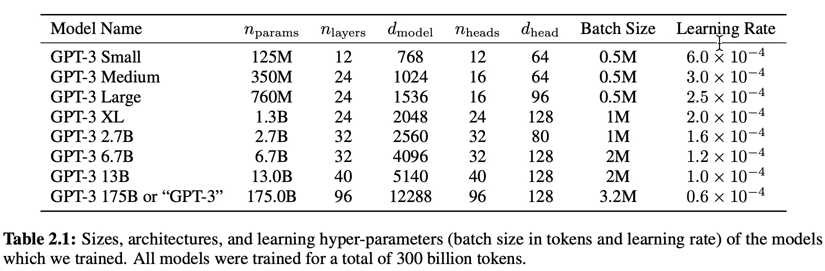

In [ ]:
def main():
  device = "cpu"
  if torch.cuda.is_available():
      device = "cuda"
  elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
      device = "mps" # Multi-Process Server
  print(f"Using device: {device}")
  
  torch.manual_seed(1337)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)
  
  # Grad Accumulation
  total_batch_size = 524288 # 2**19, ~0.5M, in number of tokens
  B = 4 # Micro batch size
  T = 32 # Sequence/Context Length 
  assert total_batch_size % (B * T) == 0, "Make sure total_batch_size is divisible by B * T"
  grad_accum_steps = total_batch_size // (B * T)
  print(f"Total desired batch size: {total_batch_size}")
  print(f"=> Calculated gradient accumulation steps: {grad_accum_steps}")
  
  # Dataset  
  # train_loader = DataLoaderLite(B=16, T=32)
  train_loader = DataLoaderLite(B=B, T=T)
  
  # Use T32 Format
  torch.set_float32_matmul_precision('high')
  
  # Model, get logits
  model = GPT(GPTConfig(vocab_size=50304))
  model.to(device) 
  model = torch.compile(model)
  
  # Optimizer
  optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), eps=1e-8)  
  max_lr = 3e-4
  min_lr = max_lr * 0.1
  warmup_steps = 10
  max_steps = 50
  
  # Scheduler
  def get_lr(it):
      # 1) Linear warmup for warmup_iters steps
      if it < warmup_steps:
          return max_lr * (it+1) / warmup_steps
      # 2) If it > lr_decay_iters, return min learning rate
      if it > max_steps:
          return min_lr
      # 3) In between, use cosine decay don to min learning rate
      decay_ratio = (it - warmup_steps) / (max_steps - warmup_steps)
      assert 0 <= decay_ratio <= 1
      coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio)) # Coeff starts at 1 and goes to 0
      return min_lr + coeff * (max_lr - min_lr)
  # NOTE: Pytorch also has a scheduler
  
  import time
  for step in range(max_steps):
    t0 = time.time()
    optimizer.zero_grad()
    
    # Grad accumulation
    loss_accum = 0.0
    for microstep in range(grad_accum_steps):
        x, y = train_loader.next_batch()
        x, y = x.to(device), y.to(device)
        with torch.autocast(device_type=device, dtype=torch.bfloat16): # <---- This line
            logits, loss = model(x, y) 
        """ Grad accum notes
        # We have to scale the loss to account for gradient accumulation,
        # because the gradients just add on each successive backward().
        # Addition of gradients corresponds to a SUM in the objective, but
        # instead of a SUM we want a MEAN. 
        # Scale the loss here so it comes out right. 
        """
        loss = loss / grad_accum_steps # For normalization: reintroduce the mean loss
        loss_accum += loss.detach()
        loss.backward()
        
    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    
    # Update learning rate
    # Determine and set the learning rate for this iteration
    lr = get_lr(step)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    
    optimizer.step()
    torch.cuda.synchronize()
    t1 = time.time()
    dt = (t1 - t0)*1000 # Time difference in milliseconds 
    tokens_processed = train_loader.B* train_loader.T * grad_accum_steps
    tokens_per_sec = tokens_processed / (t1 - t0)
    print(f"Step {step+1:4d} | Loss: {loss_accum.item():.6f} | LR: {lr:.4e} | Norm: {norm:.4f} | Dt: {dt:.2f}ms | tok/sec: {tokens_per_sec:.2f}")
      
main()

' Commented to not run this\ndef main():\n  device = "cpu"\n  if torch.cuda.is_available():\n      device = "cuda"\n  elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():\n      device = "mps" # Multi-Process Server\n  print(f"Using device: {device}")\n\n  torch.manual_seed(1337)\n  if torch.cuda.is_available():\n    torch.cuda.manual_seed(1337)\n\n  # Grad Accumulation\n  total_batch_size = 524288 # 2**19, ~0.5M, in number of tokens\n  B = 4 # Micro batch size\n  T = 32 # Sequence/Context Length \n  assert total_batch_size % (B * T) == 0, "Make sure total_batch_size is divisible by B * T"\n  grad_accum_steps = total_batch_size // (B * T)\n  print(f"Total desired batch size: {total_batch_size}")\n  print(f"=> Calculated gradient accumulation steps: {grad_accum_steps}")\n\n  # Dataset  \n  # train_loader = DataLoaderLite(B=16, T=32)\n  train_loader = DataLoaderLite(B=B, T=T)\n\n  # Use T32 Format\n  torch.set_float32_matmul_precision(\'high\')\n\n  # Model, get log

In [79]:
""" B = 4, T = 32
# Using device: cuda
# Total desired batch size: 524288
# => Calculated gradient accumulation steps: 4096
# Lines: 40000 | Words: 202651 | Bytes: 1115394
# Loaded 338025 tokens.
# 1 epoch = 2640 batches.
# Step    1 | Loss: 10.944483 | LR: 3.0000e-05 | Norm: 25.1734 | Dt: 104903.48ms | tok/sec: 4997.81
# Step    2 | Loss: 9.722869 | LR: 6.0000e-05 | Norm: 10.4026 | Dt: 90751.42ms | tok/sec: 5777.19
# Step    3 | Loss: 9.317894 | LR: 9.0000e-05 | Norm: 9.0887 | Dt: 82483.12ms | tok/sec: 6356.31
# Step    4 | Loss: 9.650971 | LR: 1.2000e-04 | Norm: 9.2345 | Dt: 92150.27ms | tok/sec: 5689.49
# Step    5 | Loss: 9.197917 | LR: 1.5000e-04 | Norm: 4.7174 | Dt: 90609.05ms | tok/sec: 5786.27
# Step    6 | Loss: 8.828031 | LR: 1.8000e-04 | Norm: 2.9305 | Dt: 90676.04ms | tok/sec: 5781.99
# Step    7 | Loss: 8.787623 | LR: 2.1000e-04 | Norm: 4.5952 | Dt: 90548.06ms | tok/sec: 5790.16
# Step    8 | Loss: 8.548655 | LR: 2.4000e-04 | Norm: 1.9561 | Dt: 90509.43ms | tok/sec: 5792.63
# Step    9 | Loss: 8.375901 | LR: 2.7000e-04 | Norm: 2.7885 | Dt: 87597.46ms | tok/sec: 5985.20
# Step   10 | Loss: 8.181180 | LR: 3.0000e-04 | Norm: 2.9373 | Dt: 86898.23ms | tok/sec: 6033.36
# Step   11 | Loss: 7.917768 | LR: 3.0000e-04 | Norm: 2.6522 | Dt: 93483.19ms | tok/sec: 5608.37
# Step   12 | Loss: 7.688158 | LR: 2.9958e-04 | Norm: 1.8799 | Dt: 93809.01ms | tok/sec: 5588.89
# Step   13 | Loss: 7.452488 | LR: 2.9834e-04 | Norm: 1.7220 | Dt: 94614.46ms | tok/sec: 5541.31
# Step   14 | Loss: 7.241179 | LR: 2.9627e-04 | Norm: 1.2868 | Dt: 94291.96ms | tok/sec: 5560.26
# Step   15 | Loss: 7.025455 | LR: 2.9339e-04 | Norm: 1.8262 | Dt: 93530.67ms | tok/sec: 5605.52
# Step   16 | Loss: 6.864443 | LR: 2.8972e-04 | Norm: 1.2300 | Dt: 93170.37ms | tok/sec: 5627.20
# Step   17 | Loss: 6.713759 | LR: 2.8529e-04 | Norm: 1.4424 | Dt: 93692.50ms | tok/sec: 5595.84
# Step   18 | Loss: 6.582439 | LR: 2.8011e-04 | Norm: 1.3137 | Dt: 93544.71ms | tok/sec: 5604.68
# Step   19 | Loss: 6.476289 | LR: 2.7422e-04 | Norm: 1.3417 | Dt: 93443.71ms | tok/sec: 5610.74
# ...
# Step   25 | Loss: 6.117889 | LR: 2.2629e-04 | Norm: 0.5109 | Dt: 87998.16ms | tok/sec: 5957.94
# Step   26 | Loss: 6.066016 | LR: 2.1666e-04 | Norm: 0.5110 | Dt: 86474.53ms | tok/sec: 6062.92
# Step   27 | Loss: 6.049117 | LR: 2.0672e-04 | Norm: 0.4173 | Dt: 86089.39ms | tok/sec: 6090.04
# Step   28 | Loss: 6.025249 | LR: 1.9652e-04 | Norm: 0.7474 | Dt: 85837.51ms | tok/sec: 6107.91
"""

' B = 4, T = 32\n# Using device: cuda\n# Total desired batch size: 524288\n# => Calculated gradient accumulation steps: 4096\n# Lines: 40000 | Words: 202651 | Bytes: 1115394\n# Loaded 338025 tokens.\n# 1 epoch = 2640 batches.\n# Step    1 | Loss: 10.944483 | LR: 3.0000e-05 | Norm: 25.1734 | Dt: 104903.48ms | tok/sec: 4997.81\n# Step    2 | Loss: 9.722869 | LR: 6.0000e-05 | Norm: 10.4026 | Dt: 90751.42ms | tok/sec: 5777.19\n# Step    3 | Loss: 9.317894 | LR: 9.0000e-05 | Norm: 9.0887 | Dt: 82483.12ms | tok/sec: 6356.31\n# Step    4 | Loss: 9.650971 | LR: 1.2000e-04 | Norm: 9.2345 | Dt: 92150.27ms | tok/sec: 5689.49\n# Step    5 | Loss: 9.197917 | LR: 1.5000e-04 | Norm: 4.7174 | Dt: 90609.05ms | tok/sec: 5786.27\n# Step    6 | Loss: 8.828031 | LR: 1.8000e-04 | Norm: 2.9305 | Dt: 90676.04ms | tok/sec: 5781.99\n# Step    7 | Loss: 8.787623 | LR: 2.1000e-04 | Norm: 4.5952 | Dt: 90548.06ms | tok/sec: 5790.16\n# Step    8 | Loss: 8.548655 | LR: 2.4000e-04 | Norm: 1.9561 | Dt: 90509.43ms | tok

NOTE:

-   For a 3060ti consumer-grade GPU which is not meant for training LLM,
-   Grad Accum significantly slows down the training process
    because grad_accum effectively <u>increases batch size</u> by accumulating gradients over multiple mini-batches before performing a single update step. 

## Distributed Data Parallel (DDP)

If you have muliple GPU setup.

In [ ]:
class DataLoaderLite:
    
    def __init__(self, B, T, process_rank, num_processes):
        self.B = B
        self.T = T
        self.process_rank = process_rank
        self.num_processes = num_processes
    
        # At init, load tokens from disk and store in memory
        text = get_dataset()
        enc = tiktoken.get_encoding('gpt2')
        tokens = enc.encode(text)
        self.tokens = torch.tensor(tokens)
        print(f"Loaded {len(self.tokens)} tokens.")
        print(f"1 epoch = {len(self.tokens) // (B*T)} batches.")
        
        # State
        # self.current_position = 0
        # Stride out the process, no longer starts at 0.
        self.current_position = self.B * self.T * self.process_rank
        
    def next_batch(self):
        B, T = self.B, self.T
        buf = self.tokens[self.current_position : self.current_position+B*T+1]
        x = (buf[:-1]).view(B, T) # Inputs
        y = (buf[1:]).view(B, T)  # Labels/Targets
        # Advance the position in tensor
        # self.current_position += B * T
        self.current_position += B * T * self.num_processes
        # If loading next batch would be out of bounds, reset
        if self.current_position + (B * T * self.num_processes + 1) > len(self.tokens):
            # self.current_position = 0
            self.current_position = self.B * self.T * self.process_rank
        return x, y

In [ ]:
def main():
  # Distributed Data Parallels (DDP)
  import os
  from torch.distributed import init_process_group, destroy_process_group
  from torch.nn.parallel import DistributedDataParallel as DDP
  import torch.distributed as dist
  
  # Setup DDP
  # torchrun command sets the env variables RANK, LOCAL_RANK, and WORLD_SIZE
  ddp = int(os.environ.get('RANK', -1)) != -1 # Is this a ddp run?
  if ddp:
      # Use of DDP atm demands CUDA, we set the device appropriately according to rank
      assert torch.cuda.is_available(), "For now I think we need CUDA for DDP"
      init_process_group(backend='nccl')
      ddp_rank = int(os.environ['RANK']) # GPU0, rank=0; GPU1, rank=1
      ddp_local_rank = int(os.environ['LOCAL_RANK']) # For multi-node settings (This model is 1 node)
      ddp_world_size = int(os.environ['WORLD_SIZE']) # Stack of 8 GPU, world_size = 8
      device = f'cuda:{ddp_local_rank}'
      torch.cuda.set_device(device)
      master_process = ddp_rank == 0 # This process will do logging, checkpointing, etc.
  else:
      # Vanilla, non-DDP run
      ddp_rank = 0
      ddp_local_rank = 0
      ddp_world_size = 1
      master_process = True
      # Attempt to autodetect device
      device = "cpu"
      if torch.cuda.is_available():
          device = "cuda"
      elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
          device = "mps"
      print(f"Using device: {device}")
      
  # Pytorch: Device vs. Device_type distinction
  device_type = "cuda" if device.startswith("cuda") else "cpu"
  
  torch.manual_seed(1337)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)
  
  # Grad Accumulation
  total_batch_size = 524288 # 2**19, ~0.5M, in number of tokens
  B = 64 # Micro batch size # Changed to match video # Since I'm not running this anyway
  T = 1024 # Sequence/Context Length 
  assert total_batch_size % (B * T * ddp_world_size) == 0, "Make sure total_batch_size is divisible by B * T * ddp_world_size"
  grad_accum_steps = total_batch_size // (B * T * ddp_world_size)
  if master_process:
    print(f"Total desired batch size: {total_batch_size}")
    print(f"=> Calculated gradient accumulation steps: {grad_accum_steps}")
  
  # Dataset
  """ Replaced with DataLoaderLite
  # Get databatch 
  text = get_dataset()
  enc = tiktoken.get_encoding('gpt2')
  data = text[:1000] # Data is first 1000 characters (~3000 tokens)
  tokens = enc.encode(data)
  buf = torch.tensor(tokens[:24+1]) # 24 = B*T # +1 is Ground truth at last token
  x = buf[:-1].view(4, 6) # Input to Transformer
  y = buf[1:].view(4, 6)# Label for training (with ground truth) 
  """
  # train_loader = DataLoaderLite(B=B, T=T)
  train_loader = DataLoaderLite(B=B, T=T, process_rank=ddp_rank, num_processes=ddp_world_size)
  
  # Use T32 Format
  torch.set_float32_matmul_precision('high')
  
  # Model, get logits
  model = GPT(GPTConfig(vocab_size=50304))
  model.to(device) 
  model = torch.compile(model)
  if ddp:
    model = DDP(model, device_ids=[ddp_local_rank])
  
  raw_model = model.module if ddp else model # Always contains the "raw" unwrapped model
  
  
  max_lr = 6e-4
  min_lr = max_lr * 0.1
  warmup_steps = 715
  max_steps = 19073 # 19,073 steps is ~1 epoch, if data is 10B tokens and batch size 0.5M tokens
  
  # Scheduler
  def get_lr(it):
      # 1) Linear warmup for warmup_iters steps
      if it < warmup_steps:
          return max_lr * (it+1) / warmup_steps
      # 2) If it > lr_decay_iters, return min learning rate
      if it > max_steps:
          return min_lr
      # 3) In between, use cosine decay don to min learning rate
      decay_ratio = (it - warmup_steps) / (max_steps - warmup_steps)
      assert 0 <= decay_ratio <= 1
      coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio)) # Coeff starts at 1 and goes to 0
      return min_lr + coeff * (max_lr - min_lr)
  # NOTE: Pytorch also has a scheduler
  
  # Optimizer
  # optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), eps=1e-8)  
  optimizer = raw_model.configure_optimizers(weight_decay=0.1, learning_rate=6e-4, device_type=device_type)
  
  import time
  for step in range(max_steps):
    t0 = time.time()
    optimizer.zero_grad()
    
    # Grad accumulation
    for microstep in range(grad_accum_steps):
        x, y = train_loader.next_batch()
        x, y = x.to(device), y.to(device)
        if ddp:
          model.require_backward_grad_sync = (microstep == grad_accum_steps - 1)
          
        with torch.autocast(device_type=device, dtype=torch.bfloat16): # <---- This line
            logits, loss = model(x, y) 
        
        """ Floating point checks
        # import code; code.interact(local=locals()) 
        # logits.dtype                          # torch.bfloat16
        # model.transformer.wte
        # model.transformer.wte.weights
        # model.transformer.wte.weights.dtype   # torch.float32
        """
        
        """ Grad accum notes
        # We have to scale the loss to account for gradient accumulation,
        # because the gradients just add on each successive backward().
        # Addition of gradients corresponds to a SUM in the objective, but
        # instead of a SUM we want a MEAN. 
        # Scale the loss here so it comes out right. 
        """
        loss = loss / grad_accum_steps # For normalization: reintroduce the mean loss
        loss_accum += loss.detach()
        loss.backward()
    # Pass the average gradient of (world_rank) next epoch's gradients
    if ddp:
        dist.all_reduce(loss_accum, op=dist.ReduceOp.AVH)    
    
    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    """clip_grad_norm notes
    # Calculate global norm of the parameters, square and add it all up, then sqrt it
    # and gradient is no more than 1.0.

    # This is used because 
    # during optimization, you may get high loss (maybe due to bad data batch or unlucky)
    # which can cause a shock to the model.
    # Clip it to prevent loss from going too big.
    
    # This can be visualized o get a good idea of how the model is going.
    """
    
    # Update learning rate
    lr = get_lr(step)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
  
    optimizer.step()
    torch.cuda.synchronize()
    t1 = time.time()
    dt = t1 - t0 # Time difference in milliseconds
    tokens_processed = train_loader.B * train_loader.T * grad_accum_steps * ddp_world_size
    tokens_per_sec = tokens_processed / dt
    if master_process:
      print(f"Step {step+1:4d} | Loss: {loss.item():.6f} | LR: {lr:.4e} | Norm: {norm:.4f} | Dt: {dt*1000:.2f}ms | tok/sec: {tokens_per_sec:.2f}")
  
  # Destroy process group at the end.
  if ddp:
    destroy_process_group()
    
# main()

'\ndef main():\n\n  # Distributed Data Parallels (DDP)\n  import os\n  from torch.distributed import init_process_group, destroy_process_group\n\n  # Setup DDP\n  # torchrun command sets the env variables RANK, LOCAL_RANK, and WORLD_SIZE\n  ddp = int(os.environ.get(\'RANK\', -1)) != -1 # Is this a ddp run?\n  if ddp:\n      # Use of DDP atm demands CUDA, we set the device appropriately according to rank\n      assert torch.cuda.is_available(), "For now I think we need CUDA for DDP"\n      init_process_group(backend=\'nccl\')\n      ddp_rank = int(os.environ[\'RANK\'])\n      ddp_local_rank = int(os.environ[\'LOCAL_RANK\'])\n      ddp_world_size = int(os.environ[\'WORLD_SIZE\']) # Stack of 8 GPU, world_size = 8\n      device = f\'cuda:{ddp_local_rank}\'\n      torch.cuda.set_device(device)\n      master_process = ddp_rank == 0 # This process will do logging, checkpointing, etc.\n  else:\n      # Vanilla, non-DDP run\n      ddp_rank = 0\n      ddp_local_rank = 0\n      ddp_world_size = 1

Each GPU runs their own script, their own B * T.

In [ ]:
# Update the following to "B * T * ddp_world_size"
# assert total_batch_size % (B * T * ddp_world_size) == 0, "Make sure total_batch_size is divisible by B * T * ddp_world_size"
# grad_accum_steps = total_batch_size // (B * T * ddp_world_size)

total_batch_size // B * T * ddp_world_size

$524288 // (16*1024*8=113,072) = 4 =$ grad_accum_steps

113,072 tokens in a single forward-backward on the 8 GPUs.

In [81]:
# if master_process:
#     print(f"Total desired batch size: {total_batch_size}")
#     print(f"=> Calculated gradient accumulation steps: {grad_accum_steps}")

# Print only once

In [ ]:
# Data Loader
# train_loader = DataLoaderLite(B=B, T=T, process_rank=ddp_rank, num_processes=ddp_world_size)

In [ ]:
# Wrap the model into the DDP Container
# if ddp:
#     model = DDP(model, device_ids=[ddp_local_rank])

In [ ]:
# Launching

# Simple launch:
# python train_gpt2.py
# DDP launch for e.g. 8 GPU
# torchrun --standalone --nproc_per_node=8 train_gpt2.py

# Dataset

1.  [Slim Pajama - 627B (895GB)](https://huggingface.co/datasets/cerebras/SlimPajama-627B) 
2. [Fine Web Dataset - 15T ](https://huggingface.co/datasets/HuggingFaceFW/fineweb)- Smaller samples available
3. [Fine Web Edu](https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu)

## Codes

In [1]:
%pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 33.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 36.1 MB/s eta 0:00:00 0:00:01
  Attempting uninstall: fsspec━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  3/17 [pyarrow]
    Found existing installation: fsspec 2025.5.1━━━━━━━━━━━━━━  3/17 [pyarrow]
    Uninstalling fsspec-2025.5.1:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  3/17 [pyarrow]
      Successfully uninstalled fsspec-2025.5.1━━━━━━━━━━━━━━━━  3/17 [pyarrow]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17/17 [datasets]/17 [datasets]ess]
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# fineweb.py
# Downloads and Loads FineWeb-Edu
"""
FineWeb-Edu dataset (for srs pretraining)
https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu
Downloads and tokenizes the data and saves data shards to disk.
Run simply as:
$ python fineweb.py
Will save shards to the local directory "edu_fineweb10B".
"""

import os
import multiprocessing as mp
import numpy as np
import tiktoken
from datasets import load_dataset # pip install datasets
from tqdm import tqdm # pip install tqdm

# ------------------------------------------
local_dir = "edu_fineweb10B"
remote_name = "sample-10BT"
shard_size = int(1e8) # 100M tokens per shard, total of 100 shards

# create the cache the local directory if it doesn't exist yet
DATA_CACHE_DIR = os.path.join(os.path.dirname(__file__), local_dir)
os.makedirs(DATA_CACHE_DIR, exist_ok=True)

# download the dataset
fw = load_dataset("HuggingFaceFW/fineweb-edu", name=remote_name, split="train")

# init the tokenizer
enc = tiktoken.get_encoding("gpt2")
eot = enc._special_tokens['<|endoftext|>'] # end of text token
def tokenize(doc):
    # tokenizes a single document and returns a numpy array of uint16 tokens
    tokens = [eot] # the special <|endoftext|> token delimits all documents
    tokens.extend(enc.encode_ordinary(doc["text"]))
    tokens_np = np.array(tokens)
    assert (0 <= tokens_np).all() and (tokens_np < 2**16).all(), "token dictionary too large for uint16"
    tokens_np_uint16 = tokens_np.astype(np.uint16)
    return tokens_np_uint16

def write_datafile(filename, tokens_np):
    np.save(filename, tokens_np)

# tokenize all documents and write output shards, each of shard_size tokens (last shard has remainder)
nprocs = max(1, os.cpu_count()//2)
with mp.Pool(nprocs) as pool:
    shard_index = 0
    # preallocate buffer to hold current shard
    all_tokens_np = np.empty((shard_size,), dtype=np.uint16)
    token_count = 0
    progress_bar = None
    for tokens in pool.imap(tokenize, fw, chunksize=16):

        # is there enough space in the current shard for the new tokens?
        if token_count + len(tokens) < shard_size:
            # simply append tokens to current shard
            all_tokens_np[token_count:token_count+len(tokens)] = tokens
            token_count += len(tokens)
            # update progress bar
            if progress_bar is None:
                progress_bar = tqdm(total=shard_size, unit="tokens", desc=f"Shard {shard_index}")
            progress_bar.update(len(tokens))
        else:
            # write the current shard and start a new one
            split = "val" if shard_index == 0 else "train"
            filename = os.path.join(DATA_CACHE_DIR, f"edufineweb_{split}_{shard_index:06d}")
            # split the document into whatever fits in this shard; the remainder goes to next one
            remainder = shard_size - token_count
            progress_bar.update(remainder)
            all_tokens_np[token_count:token_count+remainder] = tokens[:remainder]
            write_datafile(filename, all_tokens_np)
            shard_index += 1
            progress_bar = None
            # populate the next shard with the leftovers of the current doc
            all_tokens_np[0:len(tokens)-remainder] = tokens[remainder:]
            token_count = len(tokens)-remainder

    # write any remaining tokens as the last shard
    if token_count != 0:
        split = "val" if shard_index == 0 else "train"
        filename = os.path.join(DATA_CACHE_DIR, f"edufineweb_{split}_{shard_index:06d}")
        write_datafile(filename, all_tokens_np[:token_count])

In [ ]:
import tiktoken
import numpy as np

def load_tokens(filename):
    npt = np.load(filename)
    npt = npt.astype(np.int32) # added after video
    ptt = torch.tensor(npt, dtype=torch.long)
    return ptt

class DataLoaderLite:
    def __init__(self, B, T, process_rank, num_processes, split):
        self.B = B
        self.T = T
        self.process_rank = process_rank
        self.num_processes = num_processes
        assert split in {'train', 'val'}

        # get the shard filenames
        data_root = "edu_fineweb10B"
        shards = os.listdir(data_root)
        shards = [s for s in shards if split in s]
        shards = sorted(shards)
        shards = [os.path.join(data_root, s) for s in shards]
        self.shards = shards
        assert len(shards) > 0, f"no shards found for split {split}" 
        print(f"found {len(shards)} shards for split {split}")
        self.reset()

    def next_batch(self):
        B, T = self.B, self.T
        buf = self.tokens[self.current_position : self.current_position+B*T+1]
        x = (buf[:-1]).view(B, T) # inputs
        y = (buf[1:]).view(B, T) # targets
        # advance the position in the tensor
        self.current_position += B * T * self.num_processes
        # if loading the next batch would be out of bounds, advance to next shard
        if self.current_position + (B * T * self.num_processes + 1) > len(self.tokens):
            self.current_shard = (self.current_shard + 1) % len(self.shards)
            self.tokens = load_tokens(self.shards[self.current_shard])
            self.current_position = B * T * self.process_rank
        return x, y

In [ ]:
# train_loader = DataLoaderLite(B=B, T=T, process_rank=ddp_rank, num_processes=ddp_world_size, split="train")

Calculating Max steps

= Total tokens / Tokens per step

= 10e9 / 2**19 

= 19073

---

Warm up steps (GPT3)

375e6 / 2** 19 = 715 steps

---

Calculating estimate time

= Max steps * dt (seconds) * 60 (minutes) * 60 (hours)

In [ ]:
def main():
  # Distributed Data Parallels (DDP)
  import os
  from torch.distributed import init_process_group, destroy_process_group
  from torch.nn.parallel import DistributedDataParallel as DDP
  import torch.distributed as dist
  
  # Setup DDP
  # torchrun command sets the env variables RANK, LOCAL_RANK, and WORLD_SIZE
  ddp = int(os.environ.get('RANK', -1)) != -1 # Is this a ddp run?
  if ddp:
      # Use of DDP atm demands CUDA, we set the device appropriately according to rank
      assert torch.cuda.is_available(), "For now I think we need CUDA for DDP"
      init_process_group(backend='nccl')
      ddp_rank = int(os.environ['RANK']) # GPU0, rank=0; GPU1, rank=1
      ddp_local_rank = int(os.environ['LOCAL_RANK']) # For multi-node settings (This model is 1 node)
      ddp_world_size = int(os.environ['WORLD_SIZE']) # Stack of 8 GPU, world_size = 8
      device = f'cuda:{ddp_local_rank}'
      torch.cuda.set_device(device)
      master_process = ddp_rank == 0 # This process will do logging, checkpointing, etc.
  else:
      # Vanilla, non-DDP run
      ddp_rank = 0
      ddp_local_rank = 0
      ddp_world_size = 1
      master_process = True
      # Attempt to autodetect device
      device = "cpu"
      if torch.cuda.is_available():
          device = "cuda"
      elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
          device = "mps"
      print(f"Using device: {device}")
      
  # Pytorch: Device vs. Device_type distinction
  device_type = "cuda" if device.startswith("cuda") else "cpu"
  
  torch.manual_seed(1337)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)
  
  # Grad Accumulation
  total_batch_size = 524288 # 2**19, ~0.5M, in number of tokens
  B = 64 # Micro batch size # Changed to match video # Since I'm not running this anyway
  T = 1024 # Sequence/Context Length 
  # Note: No grad_accum will occur because B*T*8 == total_batch_size in Andrej's 8 GPU instance
  assert total_batch_size % (B * T * ddp_world_size) == 0, "Make sure total_batch_size is divisible by B * T * ddp_world_size"
  grad_accum_steps = total_batch_size // (B * T * ddp_world_size)
  if master_process:
    print(f"Total desired batch size: {total_batch_size}")
    print(f"=> Calculated gradient accumulation steps: {grad_accum_steps}")
  
  # Dataset
  """ Replaced with DataLoaderLite
  # Get databatch 
  text = get_dataset()
  enc = tiktoken.get_encoding('gpt2')
  data = text[:1000] # Data is first 1000 characters (~3000 tokens)
  tokens = enc.encode(data)
  buf = torch.tensor(tokens[:24+1]) # 24 = B*T # +1 is Ground truth at last token
  x = buf[:-1].view(4, 6) # Input to Transformer
  y = buf[1:].view(4, 6)# Label for training (with ground truth) 
  """
  # train_loader = DataLoaderLite(B=B, T=T)
  # train_loader = DataLoaderLite(B=B, T=T, process_rank=ddp_rank, num_processes=ddp_world_size)
  train_loader = DataLoaderLite(B=B, T=T, process_rank=ddp_rank, num_processes=ddp_world_size, split="train")
   
  # Use T32 Format
  torch.set_float32_matmul_precision('high')
  
  # Model, get logits
  model = GPT(GPTConfig(vocab_size=50304))
  model.to(device) 
  model = torch.compile(model)
  if ddp:
    model = DDP(model, device_ids=[ddp_local_rank])
  
  raw_model = model.module if ddp else model # Always contains the "raw" unwrapped model
  
  
  max_lr = 6e-4
  min_lr = max_lr * 0.1
  warmup_steps = 715
  max_steps = 19073 # 19,073 steps is ~1 epoch, if data is 10B tokens and batch size 0.5M tokens
  
  # Scheduler
  def get_lr(it):
      # 1) Linear warmup for warmup_iters steps
      if it < warmup_steps:
          return max_lr * (it+1) / warmup_steps
      # 2) If it > lr_decay_iters, return min learning rate
      if it > max_steps:
          return min_lr
      # 3) In between, use cosine decay don to min learning rate
      decay_ratio = (it - warmup_steps) / (max_steps - warmup_steps)
      assert 0 <= decay_ratio <= 1
      coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio)) # Coeff starts at 1 and goes to 0
      return min_lr + coeff * (max_lr - min_lr)
  # NOTE: Pytorch also has a scheduler
  
  # Optimizer
  # optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), eps=1e-8)  
  optimizer = raw_model.configure_optimizers(weight_decay=0.1, learning_rate=6e-4, device_type=device_type)
  
  import time
  for step in range(max_steps):
    t0 = time.time()
    optimizer.zero_grad()
    
    # Grad accumulation
    for microstep in range(grad_accum_steps):
        x, y = train_loader.next_batch()
        x, y = x.to(device), y.to(device)
        if ddp:
          model.require_backward_grad_sync = (microstep == grad_accum_steps - 1)
          
        with torch.autocast(device_type=device, dtype=torch.bfloat16): # <---- This line
            logits, loss = model(x, y) 
        
        """ Floating point checks
        # import code; code.interact(local=locals()) 
        # logits.dtype                          # torch.bfloat16
        # model.transformer.wte
        # model.transformer.wte.weights
        # model.transformer.wte.weights.dtype   # torch.float32
        """
        
        """ Grad accum notes
        # We have to scale the loss to account for gradient accumulation,
        # because the gradients just add on each successive backward().
        # Addition of gradients corresponds to a SUM in the objective, but
        # instead of a SUM we want a MEAN. 
        # Scale the loss here so it comes out right. 
        """
        loss = loss / grad_accum_steps # For normalization: reintroduce the mean loss
        loss_accum += loss.detach()
        loss.backward()
    # Pass the average gradient of (world_rank) next epoch's gradients
    if ddp:
        dist.all_reduce(loss_accum, op=dist.ReduceOp.AVH)    
    
    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    """clip_grad_norm notes
    # Calculate global norm of the parameters, square and add it all up, then sqrt it
    # and gradient is no more than 1.0.

    # This is used because 
    # during optimization, you may get high loss (maybe due to bad data batch or unlucky)
    # which can cause a shock to the model.
    # Clip it to prevent loss from going too big.
    
    # This can be visualized o get a good idea of how the model is going.
    """
    
    # Update learning rate
    lr = get_lr(step)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
  
    optimizer.step()
    torch.cuda.synchronize()
    t1 = time.time()
    dt = t1 - t0 # Time difference in milliseconds
    tokens_processed = train_loader.B * train_loader.T * grad_accum_steps * ddp_world_size
    tokens_per_sec = tokens_processed / dt
    if master_process:
      print(f"Step {step+1:4d} | Loss: {loss.item():.6f} | LR: {lr:.4e} | Norm: {norm:.4f} | Dt: {dt*1000:.2f}ms | tok/sec: {tokens_per_sec:.2f}")
  
  # Destroy process group at the end.
  if ddp:
    destroy_process_group()
    
# main()    

# Eval

In [ ]:
import tiktoken
import numpy as np

def load_tokens(filename):
    npt = np.load(filename)
    npt = npt.astype(np.int32) # added after video
    ptt = torch.tensor(npt, dtype=torch.long)
    return ptt

class DataLoaderLite:
    def __init__(self, B, T, process_rank, num_processes, split):
        self.B = B
        self.T = T
        self.process_rank = process_rank
        self.num_processes = num_processes
        assert split in {'train', 'val'}

        # get the shard filenames
        data_root = "edu_fineweb10B"
        shards = os.listdir(data_root)
        shards = [s for s in shards if split in s]
        shards = sorted(shards)
        shards = [os.path.join(data_root, s) for s in shards]
        self.shards = shards
        assert len(shards) > 0, f"no shards found for split {split}" 
        print(f"found {len(shards)} shards for split {split}")
        self.reset()

    def reset(self):
        # state, init at shard zero
        self.current_shard = 0
        self.tokens = load_tokens(self.shards[self.current_shard])
        self.current_position = self.B * self.T * self.process_rank

    def next_batch(self):
        B, T = self.B, self.T
        buf = self.tokens[self.current_position : self.current_position+B*T+1]
        x = (buf[:-1]).view(B, T) # inputs
        y = (buf[1:]).view(B, T) # targets
        # advance the position in the tensor
        self.current_position += B * T * self.num_processes
        # if loading the next batch would be out of bounds, advance to next shard
        if self.current_position + (B * T * self.num_processes + 1) > len(self.tokens):
            self.current_shard = (self.current_shard + 1) % len(self.shards)
            self.tokens = load_tokens(self.shards[self.current_shard])
            self.current_position = B * T * self.process_rank
        return x, y

In [ ]:
def main():
  # Distributed Data Parallels (DDP)
  import os
  from torch.distributed import init_process_group, destroy_process_group
  from torch.nn.parallel import DistributedDataParallel as DDP
  import torch.distributed as dist
  
  # Setup DDP
  # torchrun command sets the env variables RANK, LOCAL_RANK, and WORLD_SIZE
  ddp = int(os.environ.get('RANK', -1)) != -1 # Is this a ddp run?
  if ddp:
      # Use of DDP atm demands CUDA, we set the device appropriately according to rank
      assert torch.cuda.is_available(), "For now I think we need CUDA for DDP"
      init_process_group(backend='nccl')
      ddp_rank = int(os.environ['RANK']) # GPU0, rank=0; GPU1, rank=1
      ddp_local_rank = int(os.environ['LOCAL_RANK']) # For multi-node settings (This model is 1 node)
      ddp_world_size = int(os.environ['WORLD_SIZE']) # Stack of 8 GPU, world_size = 8
      device = f'cuda:{ddp_local_rank}'
      torch.cuda.set_device(device)
      master_process = ddp_rank == 0 # This process will do logging, checkpointing, etc.
  else:
      # Vanilla, non-DDP run
      ddp_rank = 0
      ddp_local_rank = 0
      ddp_world_size = 1
      master_process = True
      # Attempt to autodetect device
      device = "cpu"
      if torch.cuda.is_available():
          device = "cuda"
      elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
          device = "mps"
      print(f"Using device: {device}")
      
  # Pytorch: Device vs. Device_type distinction
  device_type = "cuda" if device.startswith("cuda") else "cpu"
  
  torch.manual_seed(1337)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)
  
  # Grad Accumulation
  total_batch_size = 524288 # 2**19, ~0.5M, in number of tokens
  B = 64 # Micro batch size # Changed to match video # Since I'm not running this anyway
  T = 1024 # Sequence/Context Length 
  # Note: No grad_accum will occur because B*T*8 == total_batch_size in Andrej's 8 GPU instance
  assert total_batch_size % (B * T * ddp_world_size) == 0, "Make sure total_batch_size is divisible by B * T * ddp_world_size"
  grad_accum_steps = total_batch_size // (B * T * ddp_world_size)
  if master_process:
    print(f"Total desired batch size: {total_batch_size}")
    print(f"=> Calculated gradient accumulation steps: {grad_accum_steps}")
  
  # Dataset
  """ Replaced with DataLoaderLite
  # Get databatch 
  text = get_dataset()
  enc = tiktoken.get_encoding('gpt2')
  data = text[:1000] # Data is first 1000 characters (~3000 tokens)
  tokens = enc.encode(data)
  buf = torch.tensor(tokens[:24+1]) # 24 = B*T # +1 is Ground truth at last token
  x = buf[:-1].view(4, 6) # Input to Transformer
  y = buf[1:].view(4, 6)# Label for training (with ground truth) 
  """
  # train_loader = DataLoaderLite(B=B, T=T)
  # train_loader = DataLoaderLite(B=B, T=T, process_rank=ddp_rank, num_processes=ddp_world_size)
  train_loader = DataLoaderLite(B=B, T=T, process_rank=ddp_rank, num_processes=ddp_world_size, split="train")
  val_loader = DataLoaderLite(B=B, T=T, process_rank=ddp_rank, num_processes=ddp_world_size, split="val")

  # Use T32 Format
  torch.set_float32_matmul_precision('high')
  
  # Model, get logits
  model = GPT(GPTConfig(vocab_size=50304))
  model.to(device) 
  model = torch.compile(model)
  if ddp:
    model = DDP(model, device_ids=[ddp_local_rank])
  
  raw_model = model.module if ddp else model # Always contains the "raw" unwrapped model
  
  
  max_lr = 6e-4
  min_lr = max_lr * 0.1
  warmup_steps = 715
  max_steps = 19073 # 19,073 steps is ~1 epoch, if data is 10B tokens and batch size 0.5M tokens
  
  # Scheduler
  def get_lr(it):
      # 1) Linear warmup for warmup_iters steps
      if it < warmup_steps:
          return max_lr * (it+1) / warmup_steps
      # 2) If it > lr_decay_iters, return min learning rate
      if it > max_steps:
          return min_lr
      # 3) In between, use cosine decay don to min learning rate
      decay_ratio = (it - warmup_steps) / (max_steps - warmup_steps)
      assert 0 <= decay_ratio <= 1
      coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio)) # Coeff starts at 1 and goes to 0
      return min_lr + coeff * (max_lr - min_lr)
  # NOTE: Pytorch also has a scheduler
  
  # Optimizer
  # optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), eps=1e-8)  
  optimizer = raw_model.configure_optimizers(weight_decay=0.1, learning_rate=6e-4, device_type=device_type)
  
  import time
  for step in range(max_steps):
    t0 = time.time()
    
    # Once in a while, evaluate validation loss
    if step % 100 == 0:
        model.eval()
        val_loader.reset()
        with torch.no_grad():
            val_loss_accum = 0.0
            val_loss_steps = 20
            for _ in range(val_loss_steps):
                x, y = val_loader.next_batch()
                x, y = x.to(device), y.to(device)
                with torch.autocast(device_type=device, dtype=torch.bfloat16):
                    logits, loss = model(x, y)
                loss = loss / val_loss_steps
                val_loss_accum += loss.detach()
                
        if ddp:
            dist.all_reduce(val_loss_accum, op=dist.ReduceOp.AVG)
        if master_process:
            print(f"Validation loss: {val_loss_accum.item():.4f}")
    
    
    # Training loop
    model.train()
    optimizer.zero_grad()
    loss_accum = 0.0
    
    # Grad accumulation
    for microstep in range(grad_accum_steps):
        x, y = train_loader.next_batch()
        x, y = x.to(device), y.to(device)
        if ddp:
          model.require_backward_grad_sync = (microstep == grad_accum_steps - 1)
          
        with torch.autocast(device_type=device, dtype=torch.bfloat16): # <---- This line
            logits, loss = model(x, y) 
        
        """ Floating point checks
        # import code; code.interact(local=locals()) 
        # logits.dtype                          # torch.bfloat16
        # model.transformer.wte
        # model.transformer.wte.weights
        # model.transformer.wte.weights.dtype   # torch.float32
        """
        
        """ Grad accum notes
        # We have to scale the loss to account for gradient accumulation,
        # because the gradients just add on each successive backward().
        # Addition of gradients corresponds to a SUM in the objective, but
        # instead of a SUM we want a MEAN. 
        # Scale the loss here so it comes out right. 
        """
        loss = loss / grad_accum_steps # For normalization: reintroduce the mean loss
        loss_accum += loss.detach()
        loss.backward()
    # Pass the average gradient of (world_rank) next epoch's gradients
    if ddp:
        dist.all_reduce(loss_accum, op=dist.ReduceOp.AVH)    
    
    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    """clip_grad_norm notes
    # Calculate global norm of the parameters, square and add it all up, then sqrt it
    # and gradient is no more than 1.0.

    # This is used because 
    # during optimization, you may get high loss (maybe due to bad data batch or unlucky)
    # which can cause a shock to the model.
    # Clip it to prevent loss from going too big.
    
    # This can be visualized o get a good idea of how the model is going.
    """
    
    # Update learning rate
    lr = get_lr(step)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
  
    optimizer.step()
    torch.cuda.synchronize()
    t1 = time.time()
    dt = t1 - t0 # Time difference in milliseconds
    tokens_processed = train_loader.B * train_loader.T * grad_accum_steps * ddp_world_size
    tokens_per_sec = tokens_processed / dt
    if master_process:
      print(f"Step {step+1:4d} | Loss: {loss.item():.6f} | LR: {lr:.4e} | Norm: {norm:.4f} | Dt: {dt*1000:.2f}ms | tok/sec: {tokens_per_sec:.2f}")
  
  # Destroy process group at the end.
  if ddp:
    destroy_process_group()
    
# main()    

## Generate Samples once in a while

In [ ]:
def main():
  # Distributed Data Parallels (DDP)
  import os
  from torch.distributed import init_process_group, destroy_process_group
  from torch.nn.parallel import DistributedDataParallel as DDP
  import torch.distributed as dist
  
  # Setup DDP
  # torchrun command sets the env variables RANK, LOCAL_RANK, and WORLD_SIZE
  ddp = int(os.environ.get('RANK', -1)) != -1 # Is this a ddp run?
  if ddp:
      # Use of DDP atm demands CUDA, we set the device appropriately according to rank
      assert torch.cuda.is_available(), "For now I think we need CUDA for DDP"
      init_process_group(backend='nccl')
      ddp_rank = int(os.environ['RANK']) # GPU0, rank=0; GPU1, rank=1
      ddp_local_rank = int(os.environ['LOCAL_RANK']) # For multi-node settings (This model is 1 node)
      ddp_world_size = int(os.environ['WORLD_SIZE']) # Stack of 8 GPU, world_size = 8
      device = f'cuda:{ddp_local_rank}'
      torch.cuda.set_device(device)
      master_process = ddp_rank == 0 # This process will do logging, checkpointing, etc.
  else:
      # Vanilla, non-DDP run
      ddp_rank = 0
      ddp_local_rank = 0
      ddp_world_size = 1
      master_process = True
      # Attempt to autodetect device
      device = "cpu"
      if torch.cuda.is_available():
          device = "cuda"
      elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
          device = "mps"
      print(f"Using device: {device}")
      
  # Pytorch: Device vs. Device_type distinction
  device_type = "cuda" if device.startswith("cuda") else "cpu"
  
  torch.manual_seed(1337)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)
  
  # Grad Accumulation
  total_batch_size = 524288 # 2**19, ~0.5M, in number of tokens
  B = 64 # Micro batch size # Changed to match video # Since I'm not running this anyway
  T = 1024 # Sequence/Context Length 
  # Note: No grad_accum will occur because B*T*8 == total_batch_size in Andrej's 8 GPU instance
  assert total_batch_size % (B * T * ddp_world_size) == 0, "Make sure total_batch_size is divisible by B * T * ddp_world_size"
  grad_accum_steps = total_batch_size // (B * T * ddp_world_size)
  if master_process:
    print(f"Total desired batch size: {total_batch_size}")
    print(f"=> Calculated gradient accumulation steps: {grad_accum_steps}")
  
  # Dataset
  """ Replaced with DataLoaderLite
  # Get databatch 
  text = get_dataset()
  enc = tiktoken.get_encoding('gpt2')
  data = text[:1000] # Data is first 1000 characters (~3000 tokens)
  tokens = enc.encode(data)
  buf = torch.tensor(tokens[:24+1]) # 24 = B*T # +1 is Ground truth at last token
  x = buf[:-1].view(4, 6) # Input to Transformer
  y = buf[1:].view(4, 6)# Label for training (with ground truth) 
  """
  # train_loader = DataLoaderLite(B=B, T=T)
  # train_loader = DataLoaderLite(B=B, T=T, process_rank=ddp_rank, num_processes=ddp_world_size)
  train_loader = DataLoaderLite(B=B, T=T, process_rank=ddp_rank, num_processes=ddp_world_size, split="train")
  val_loader = DataLoaderLite(B=B, T=T, process_rank=ddp_rank, num_processes=ddp_world_size, split="val")

  # Use T32 Format
  torch.set_float32_matmul_precision('high')
  
  # Model, get logits
  model = GPT(GPTConfig(vocab_size=50304))
  model.to(device) 
  model = torch.compile(model)
  if ddp:
    model = DDP(model, device_ids=[ddp_local_rank])
  
  raw_model = model.module if ddp else model # Always contains the "raw" unwrapped model
  
  
  max_lr = 6e-4
  min_lr = max_lr * 0.1
  warmup_steps = 715
  max_steps = 19073 # 19,073 steps is ~1 epoch, if data is 10B tokens and batch size 0.5M tokens
  
  # Scheduler
  def get_lr(it):
      # 1) Linear warmup for warmup_iters steps
      if it < warmup_steps:
          return max_lr * (it+1) / warmup_steps
      # 2) If it > lr_decay_iters, return min learning rate
      if it > max_steps:
          return min_lr
      # 3) In between, use cosine decay don to min learning rate
      decay_ratio = (it - warmup_steps) / (max_steps - warmup_steps)
      assert 0 <= decay_ratio <= 1
      coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio)) # Coeff starts at 1 and goes to 0
      return min_lr + coeff * (max_lr - min_lr)
  # NOTE: Pytorch also has a scheduler
  
  # Optimizer
  # optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), eps=1e-8)  
  optimizer = raw_model.configure_optimizers(weight_decay=0.1, learning_rate=6e-4, device_type=device_type)
  
  import time
  for step in range(max_steps):
    t0 = time.time()
    
    # Once in a while, evaluate validation loss
    if step % 100 == 0:
        model.eval()
        val_loader.reset()
        with torch.no_grad():
            val_loss_accum = 0.0
            val_loss_steps = 20
            for _ in range(val_loss_steps):
                x, y = val_loader.next_batch()
                x, y = x.to(device), y.to(device)
                with torch.autocast(device_type=device, dtype=torch.bfloat16):
                    logits, loss = model(x, y)
                loss = loss / val_loss_steps
                val_loss_accum += loss.detach()
                
        if ddp:
            dist.all_reduce(val_loss_accum, op=dist.ReduceOp.AVG)
        if master_process:
            print(f"Validation loss: {val_loss_accum.item():.4f}")
    
    
    # Training loop
    model.train()
    optimizer.zero_grad()
    loss_accum = 0.0
    
    # Grad accumulation
    for microstep in range(grad_accum_steps):
        x, y = train_loader.next_batch()
        x, y = x.to(device), y.to(device)
        if ddp:
          model.require_backward_grad_sync = (microstep == grad_accum_steps - 1)
          
        with torch.autocast(device_type=device, dtype=torch.bfloat16): # <---- This line
            logits, loss = model(x, y) 
        
        """ Floating point checks
        # import code; code.interact(local=locals()) 
        # logits.dtype                          # torch.bfloat16
        # model.transformer.wte
        # model.transformer.wte.weights
        # model.transformer.wte.weights.dtype   # torch.float32
        """
        
        """ Grad accum notes
        # We have to scale the loss to account for gradient accumulation,
        # because the gradients just add on each successive backward().
        # Addition of gradients corresponds to a SUM in the objective, but
        # instead of a SUM we want a MEAN. 
        # Scale the loss here so it comes out right. 
        """
        loss = loss / grad_accum_steps # For normalization: reintroduce the mean loss
        loss_accum += loss.detach()
        loss.backward()
    # Pass the average gradient of (world_rank) next epoch's gradients
    if ddp:
        dist.all_reduce(loss_accum, op=dist.ReduceOp.AVH)    
    
    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    """clip_grad_norm notes
    # Calculate global norm of the parameters, square and add it all up, then sqrt it
    # and gradient is no more than 1.0.

    # This is used because 
    # during optimization, you may get high loss (maybe due to bad data batch or unlucky)
    # which can cause a shock to the model.
    # Clip it to prevent loss from going too big.
    
    # This can be visualized o get a good idea of how the model is going.
    """
    
    # Update learning rate
    lr = get_lr(step)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
  
    optimizer.step()
    torch.cuda.synchronize()
    t1 = time.time()
    dt = t1 - t0 # Time difference in milliseconds
    tokens_processed = train_loader.B * train_loader.T * grad_accum_steps * ddp_world_size
    tokens_per_sec = tokens_processed / dt
    if master_process:
      print(f"Step {step+1:4d} | Loss: {loss.item():.6f} | LR: {lr:.4e} | Norm: {norm:.4f} | Dt: {dt*1000:.2f}ms | tok/sec: {tokens_per_sec:.2f}")
  
  # Destroy process group at the end.
  if ddp:
    destroy_process_group()
    
# main()    